## Configuración:
* Importación Librerias
* Definición rutas
* Definición funciones auxiliares

In [1]:
# Reload modulos automaticamente
%load_ext autoreload
%autoreload 2

from modules.gnn_models import (
    GCN2L,
    GraphSAGE2L,
    GAT2L,
    GCN3L,
    GraphSAGE3L,
    GAT3L,
    GCNSampler2L,
    GraphSAGESample2L,
    GATSample2L
)
import torch.nn as nn
import os
from modules.gnn import GNN
import dgl
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import dgl.function as fn
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, r2_score
)

print("DGL:", dgl.__version__, " | PyTorch:", torch.__version__)
TOR_LABELS_DICT = {'P2P': 0, 'C2P': 1, 'P2C': 2}

DGL: 1.1.3  | PyTorch: 2.3.0+cu121


## Aprender Embeddings

In [2]:
from pathlib import Path

# Archivos del nuevo formato de grafo (nodos/aristas)
data_path = "/media/vale/KINGSTON/TESIS/data_2026/"
nodes_file = data_path + "/nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv"
edges_file = data_path + "/edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv"

ribs_file = data_path + "/rib_20260301_0000_to_20260302_0000.txt"
if not Path(nodes_file).exists():
    raise FileNotFoundError(f"No existe el archivo de nodos: {nodes_file}")
if not Path(edges_file).exists():
    raise FileNotFoundError(f"No existe el archivo de aristas: {edges_file}")
if not Path(ribs_file).exists():
    raise FileNotFoundError(f"No existe el archivo de RIBs: {ribs_file}")

print(f"Nodos: {nodes_file}")
print(f"Aristas: {edges_file}")

Nodos: /media/vale/KINGSTON/TESIS/data_2026//nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv
Aristas: /media/vale/KINGSTON/TESIS/data_2026//edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv


## Funciones Auxiliares

In [3]:
def compute_auc(pos_score, neg_score):
    pos_score = pos_score.squeeze(-1) if pos_score.dim() > 1 else pos_score
    neg_score = neg_score.squeeze(-1) if neg_score.dim() > 1 else neg_score
    scores = torch.cat([pos_score, neg_score]).numpy()
    labels = torch.cat([torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])]).numpy()
    return roc_auc_score(labels, scores)


def compute_loss(pos_score, neg_score):
    pos_score = pos_score.squeeze(-1) if pos_score.dim() > 1 else pos_score
    neg_score = neg_score.squeeze(-1) if neg_score.dim() > 1 else neg_score
    scores = torch.cat([pos_score, neg_score])
    labels = torch.cat([torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])])
    return F.binary_cross_entropy_with_logits(scores, labels)


def compute_accuracy(pos_score, neg_score, threshold=0.5):
    pos_score = pos_score.squeeze(-1) if pos_score.dim() > 1 else pos_score
    neg_score = neg_score.squeeze(-1) if neg_score.dim() > 1 else neg_score
    scores = torch.cat([pos_score, neg_score])
    labels = torch.cat([torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])])
    preds = (scores > threshold).float()
    acc = (preds == labels).sum().item() / len(labels)
    print(f'Accuracy: {acc:.4f} (Threshold: {threshold:.2f})')
    return acc


def plot_roc_with_distributions(pos_score, neg_score, model_name, caso):
    pos_score = pos_score.squeeze(-1) if pos_score.dim() > 1 else pos_score
    neg_score = neg_score.squeeze(-1) if neg_score.dim() > 1 else neg_score
    scores = torch.cat([pos_score, neg_score]).numpy()
    labels = torch.cat([torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])]).numpy()
    fpr, tpr, thresholds = roc_curve(labels, scores)
    auc = roc_auc_score(labels, scores)
    distances = np.sqrt((1 - tpr) ** 2 + fpr ** 2)
    optimal_idx = np.argmin(distances)
    optimal_threshold = thresholds[optimal_idx]
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].hist(pos_score.numpy(), bins=50, alpha=0.5, label='Positivos', color='skyblue')
    ax[0].hist(neg_score.numpy(), bins=50, alpha=0.5, label='Negativos', color='salmon')
    ax[0].axvline(x=optimal_threshold, color='red', linestyle='--',
                  label=f'Umbral={optimal_threshold:.3f}')
    ax[0].set_xlabel('Score'); ax[0].set_ylabel('Frecuencia')
    ax[0].set_title(f'Distribución de Scores: {model_name}'); ax[0].legend()
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC={auc:.4f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    ax[1].scatter([fpr[optimal_idx]], [tpr[optimal_idx]], color='red', zorder=5,
                  label='Umbral optimo')
    ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR')
    ax[1].set_title(f'Curva ROC - {caso}: {model_name}'); ax[1].legend(loc='lower right')
    plt.tight_layout()
    save_dir = data_path + f'results/EnfoquePorPartes/{caso}'
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f'{save_dir}/roc_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return optimal_threshold


def plot_loss_evolution(train_losses, num_epochs=None, title='Loss Evolution',
                        val_losses=None, test_losses=None):
    secondary = val_losses if val_losses is not None else test_losses
    ep = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(ep, train_losses, label='Train Loss', linewidth=1.5)
    if secondary is not None:
        plt.plot(ep, secondary[:len(train_losses)], label='Val Loss', linewidth=1.5)
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(title)
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## Casos


In [ ]:
import time

GLOBAL_CONFIG = {
    'lr':           0.0005,
    'hidden_dim':   256,
    'out_dim':      128,
    'dropout':      0.3,
    'epochs':       500,
    'patience':     80,
    'weight_decay': 5e-4,
    'label_smooth': 0.05,    # Ayuda a que el modelo no sea "demasiado seguro" de clases erróneas
}

### Caso 0: Predicción de enlaces utilizando grafo con atributos de nodos extraídos de Peerin

In [27]:
# Modelos a entrenar - Caso 0
models = {
    'GCN': GCN3L,
    'GraphSAGE': GraphSAGE3L,
    'GAT': GAT3L,
}

# models = {
#     'GCN': GCN2L,
#     'GraphSAGE': GraphSAGE2L,
#     'GAT': GAT2L,
# }

In [29]:
# 1. Cargar datos con el nuevo formato (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))


gnn.split_edges_link_prediction(0.8)


g0 = gnn.dgl_graph
print("\n[Resumen grafo cargado]")
print(f"- Nodos: {g0.num_nodes():,}")
print(f"- Aristas: {g0.num_edges():,}")
print(f"- Dimensión de features: {g0.ndata['feat'].shape[1]}")
print(f"- Edges data keys: {list(g0.edata.keys())}")
# print(f"- Train edges: {g0.edata['train_mask'].sum().item():,}")
# print(f"- Val edges: {g0.edata['val_mask'].sum().item():,}")
# print(f"- Test edges: {g0.edata['test_mask'].sum().item():,}")
# if "label" in g0.edata:
#     print(f"- Distribución de label (global): {Counter(g0.edata['label'].tolist())}")
#     tr = g0.edata['label'][g0.edata['train_mask']]
#     va = g0.edata['label'][g0.edata['val_mask']]
#     te = g0.edata['label'][g0.edata['test_mask']]
#     print(f"- Distribución train: {Counter(tr.tolist())}")
#     print(f"- Distribución val:   {Counter(va.tolist())}")
#     print(f"- Distribución test:  {Counter(te.tolist())}")

Grafo cargado: 79504 nodos, 807496 aristas
Aristas en ambos sentidos: True
Dimensión de entrada (in_feats): 72
Edge features: 1 dim
[split_basic] +pos train=645996  +pos test=161500
[split_basic] -neg train=645996 -neg test=161500

[Resumen grafo cargado]
- Nodos: 79,504
- Aristas: 807,496
- Dimensión de features: 72
- Edges data keys: ['label', 'edge_feat']


Encoder: GNN + Decoder: DotProduct

In [ ]:
import os
attr = 'mis_attr_marzo'
decoder = 'DotProduct'
in_feats      = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats  = GLOBAL_CONFIG['hidden_dim']
out_feats     = GLOBAL_CONFIG['out_dim']
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso0'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [DotProduct] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=out_feats,
        out_feats_mlp=out_feats_mlp,
    )
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=GLOBAL_CONFIG['lr'],
                                 weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    t0 = time.perf_counter()
    for e in range(GLOBAL_CONFIG['epochs']):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeDotProduct(gnn.train_pos_g, h)
        neg_score = model.decodeDotProduct(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeDotProduct(gnn.test_pos_g, h_eval),
                model.decodeDotProduct(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= GLOBAL_CONFIG['patience']:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break
    tiempo_total = time.perf_counter() - t0
    print(f'Modelo {model_name} finalizado en {tiempo_total:.2f} segundos')

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (DotProduct): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeDotProduct(gnn.test_pos_g, best_h)
        neg_score = model.decodeDotProduct(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_DotProduct_' + attr, 'Caso0')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()


Training model: GCN [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.5176  val=0.4940
  Epoch  10: train=0.5061  val=0.4869
  Epoch  20: train=0.4713  val=0.4664
  Epoch  30: train=0.4593  val=0.4669
  Epoch  40: train=0.4557  val=0.4664
  Epoch  50: train=0.4552  val=0.4645
  Epoch  60: train=0.4545  val=0.4636
  Epoch  70: train=0.4526  val=0.4628
  Epoch  80: train=0.4525  val=0.4620
  Epoch  90: train=0.4513  val=0.4613
  Epoch 100: train=0.4508  val=0.4606
  Epoch 110: train=0.4493  val=0.4602
  Epoch 120: train=0.4483  val=0.4597
  Epoch 130: train=0.4486  val=0.4592
  Epoch 140: train=0.4465  val=0.4589
  Epoch 150: train=0.4459  val=0.4586
  Epoch 160: train=0.4461  val=0.4586


MLP


Training model: GCN [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6835  val=0.5090
  Epoch  10: train=0.3889  val=0.3807
  Epoch  20: train=0.2223  val=0.2120
  Epoch  30: train=0.2065  val=0.2017
  Epoch  40: train=0.1897  val=0.1876
  Epoch  50: train=0.1810  val=0.1838
  Epoch  60: train=0.1747  val=0.1800
  Epoch  70: train=0.1703  val=0.1752
  Epoch  80: train=0.1656  val=0.1711
  Epoch  90: train=0.1632  val=0.1682
  Epoch 100: train=0.1618  val=0.1655
  Epoch 110: train=0.1597  val=0.1637
  Epoch 120: train=0.1580  val=0.1645
  Epoch 130: train=0.1564  val=0.1625
  Epoch 140: train=0.1559  val=0.1628
  Epoch 150: train=0.1558  val=0.1621
  Epoch 160: train=0.1559  val=0.1624
  Early stopping epoch 162. Best val loss: 0.1618
Modelo GCN finalizado en 340.78 segundos


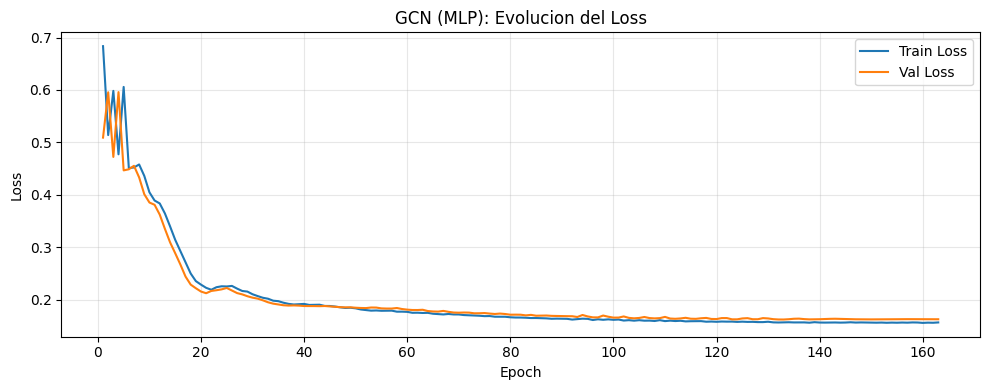

AUC: 0.9832937561943467


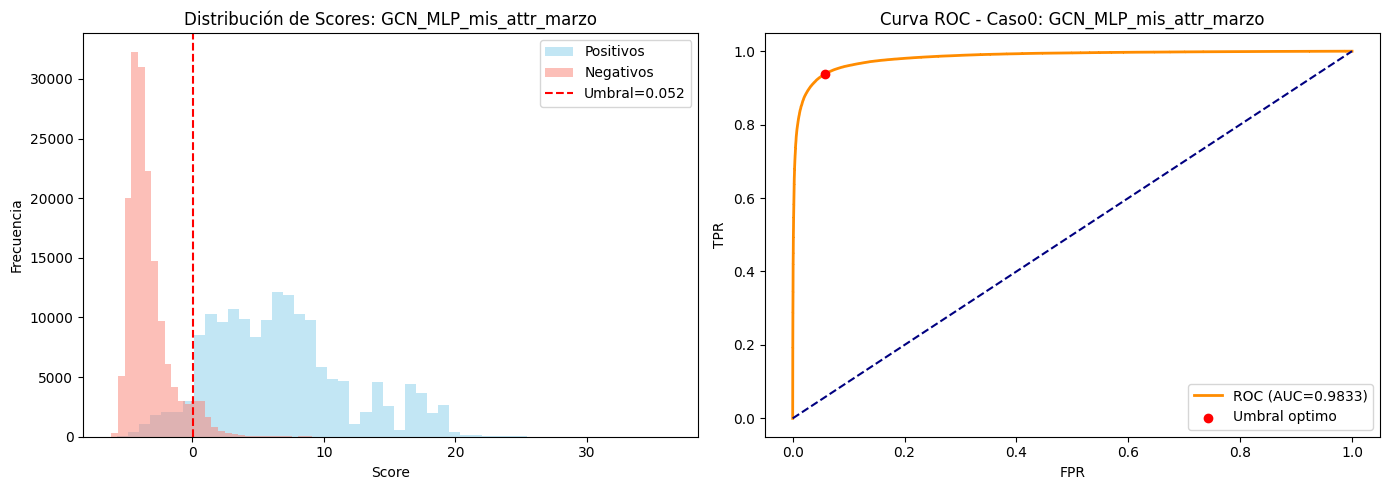

Accuracy: 0.9401 (Threshold: 0.05)


Training model: GraphSAGE [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.7141  val=0.8952
  Epoch  10: train=0.4895  val=0.4002
  Epoch  20: train=0.3809  val=0.3773
  Epoch  30: train=0.2940  val=0.2990
  Epoch  40: train=0.2196  val=0.2243
  Epoch  50: train=0.1886  val=0.2187
  Epoch  60: train=0.1770  val=0.1924
  Epoch  70: train=0.1662  val=0.1866
  Epoch  80: train=0.1626  val=0.1857
  Epoch  90: train=0.1609  val=0.1844
  Epoch 100: train=0.1562  val=0.1820
  Epoch 110: train=0.1538  val=0.1817
  Epoch 120: train=0.1511  val=0.1799
  Epoch 130: train=0.1502  val=0.1798
  Epoch 140: train=0.1504  val=0.1799
  Epoch 150: train=0.1496  val=0.1793
  Epoch 160: train=0.1492  val=0.1794
  Epoch 170: train=0.1497  val=0.1789
  Epoch 180: train=0.1495  val=0.1791
  Epoch 190: train=0.1500  val=0.1792
  Epoch 200: train=0.1493  val=0.1792
  Early stopping epoch 201. Best val loss: 0.1789
Modelo GraphSAGE finalizado en 424.07 segundos


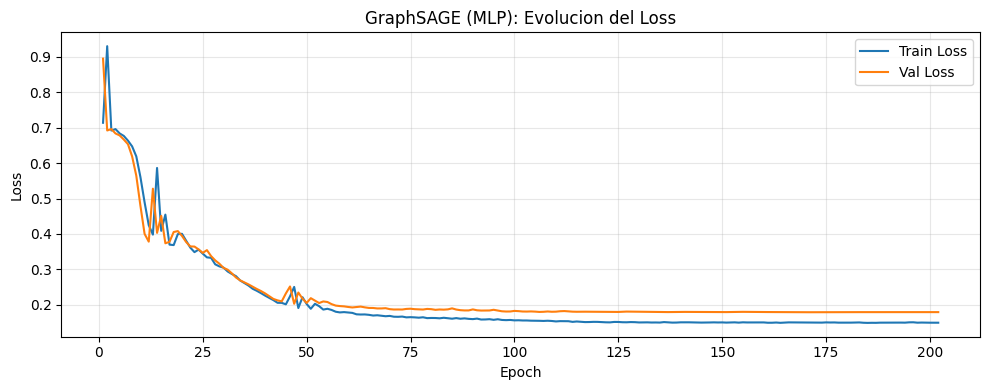

AUC: 0.9815262014205064


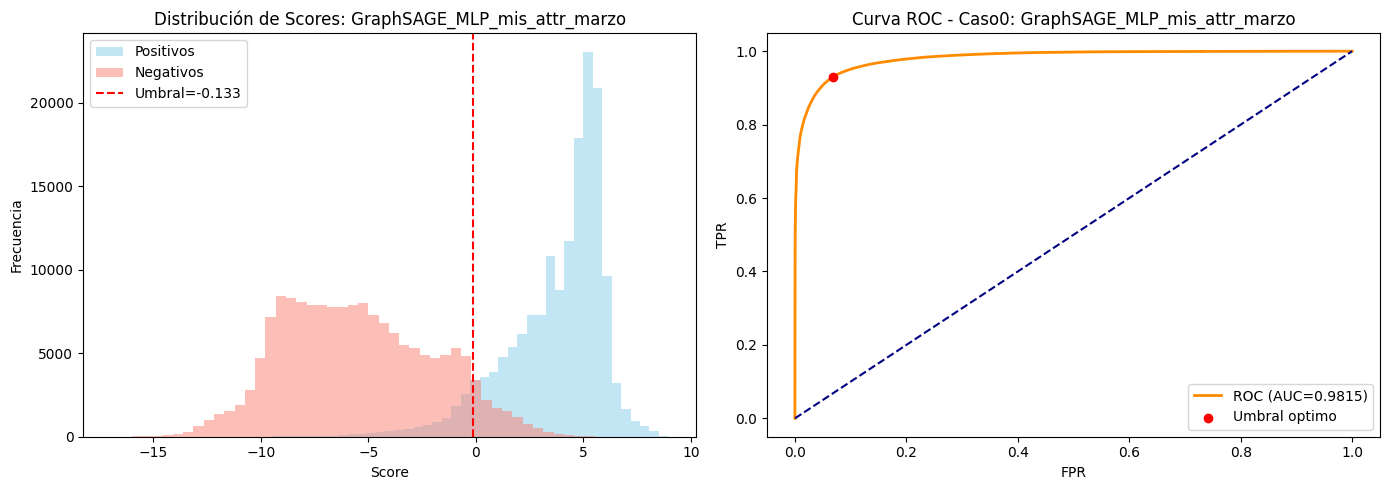

Accuracy: 0.9309 (Threshold: -0.13)


Training model: GAT [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6982  val=0.7167
  Epoch  10: train=0.5483  val=0.6324
  Epoch  20: train=0.5584  val=0.5938
  Epoch  30: train=0.4473  val=0.5105
  Epoch  40: train=0.3803  val=0.4510
  Epoch  50: train=0.3400  val=0.3726
  Epoch  60: train=0.2679  val=0.2917
  Epoch  70: train=0.2415  val=0.3240
  Epoch  80: train=0.2319  val=0.2789
  Epoch  90: train=0.2253  val=0.2521
  Epoch 100: train=0.2248  val=0.2499
  Epoch 110: train=0.2230  val=0.2452
  Early stopping epoch 112. Best val loss: 0.2414
Modelo GAT finalizado en 291.94 segundos


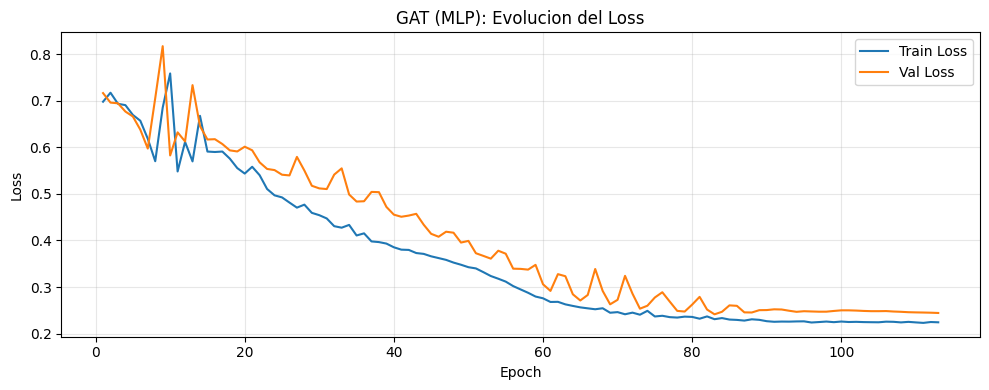

AUC: 0.9633751702786377


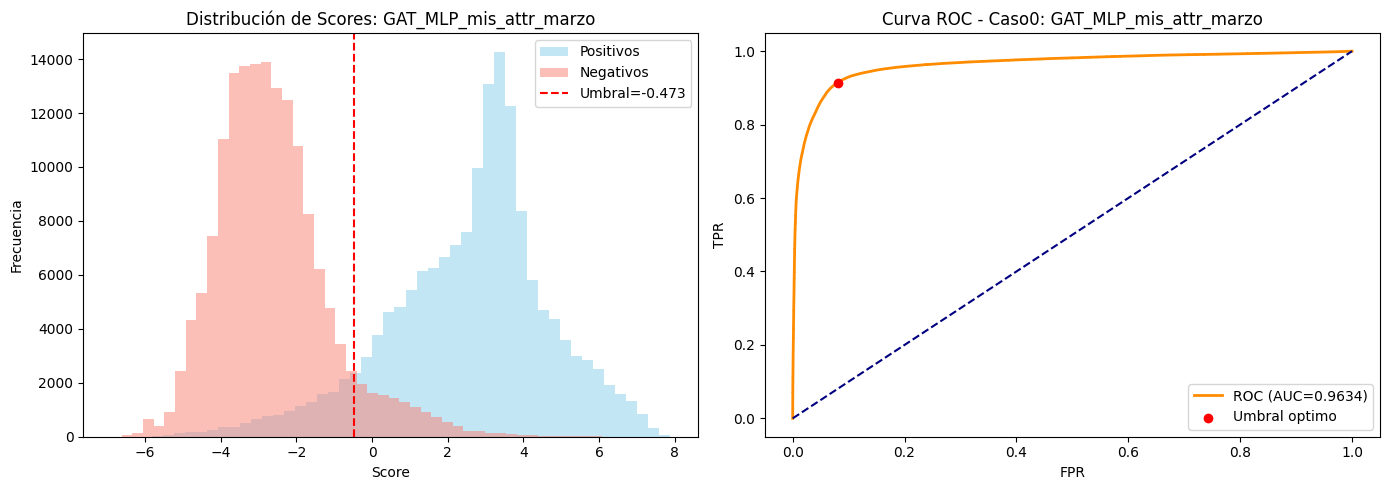

Accuracy: 0.9169 (Threshold: -0.47)



In [ ]:
# attr definido en celda anterior
decoder = 'MLP'
in_feats      = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats  = GLOBAL_CONFIG['hidden_dim']
out_feats     = GLOBAL_CONFIG['out_dim']
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso0'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [MLP] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=out_feats,
        out_feats_mlp=out_feats_mlp,
    )
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=GLOBAL_CONFIG['lr'],
                                 weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    t0 = time.perf_counter()
    for e in range(GLOBAL_CONFIG['epochs']):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeMLP(gnn.train_pos_g, h)
        neg_score = model.decodeMLP(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeMLP(gnn.test_pos_g, h_eval),
                model.decodeMLP(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= GLOBAL_CONFIG['patience']:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break
    tiempo_total = time.perf_counter() - t0
    print(f'Modelo {model_name} finalizado en {tiempo_total:.2f} segundos')

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (MLP): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeMLP(gnn.test_pos_g, best_h)
        neg_score = model.decodeMLP(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_MLP_' + attr, 'Caso0')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()

### Caso 1: Predicción de enlaces utilizando grafo con atributos de centralidad

In [ ]:
models = {
    'GCN': GCN3L,
    'GraphSAGE': GraphSAGE3L,
    'GAT': GAT3L,
}

# models = {
#     'GCN': GCN2L,
#     'GraphSAGE': GraphSAGE2L,
#     'GAT': GAT2L,
# }

# CASO 1: Grafo con atributos de grado de entrada y salida:
# ---------------------------------------
attr = 'grado_attr_febrero' 


In [ ]:
# 1. Cargar datos con el nuevo formato (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))

gnn.split_edges_link_prediction(0.8)

g0 = gnn.dgl_graph
print("\n[Resumen grafo cargado]")
print(f"- Nodos: {g0.num_nodes():,}")
print(f"- Aristas: {g0.num_edges():,}")
print(f"- Dimensión de features: {g0.ndata['feat'].shape[1]}")
print(f"- Edges data keys: {list(g0.edata.keys())}")

Grafo cargado: 79504 nodos, 807496 aristas
Aristas en ambos sentidos: True
Dimensión de entrada (in_feats): 72
Edge features: 1 dim
[split_basic] +pos train=645996  +pos test=161500
[split_basic] -neg train=645996 -neg test=161500

[Resumen grafo cargado]
- Nodos: 79,504
- Aristas: 807,496
- Dimensión de features: 72
- Edges data keys: ['label', 'edge_feat']


DotProduct


Training model: GCN [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.5177  val=0.4928
  Epoch  10: train=0.5070  val=0.4887
  Epoch  20: train=0.4708  val=0.4667
  Epoch  30: train=0.4595  val=0.4674
  Epoch  40: train=0.4539  val=0.4647
  Epoch  50: train=0.4502  val=0.4620
  Epoch  60: train=0.4469  val=0.4615
  Epoch  70: train=0.4455  val=0.4611
  Epoch  80: train=0.4444  val=0.4615
  Epoch  90: train=0.4442  val=0.4617
  Early stopping epoch 98. Best val loss: 0.4611
Modelo GCN finalizado en 65.19 segundos


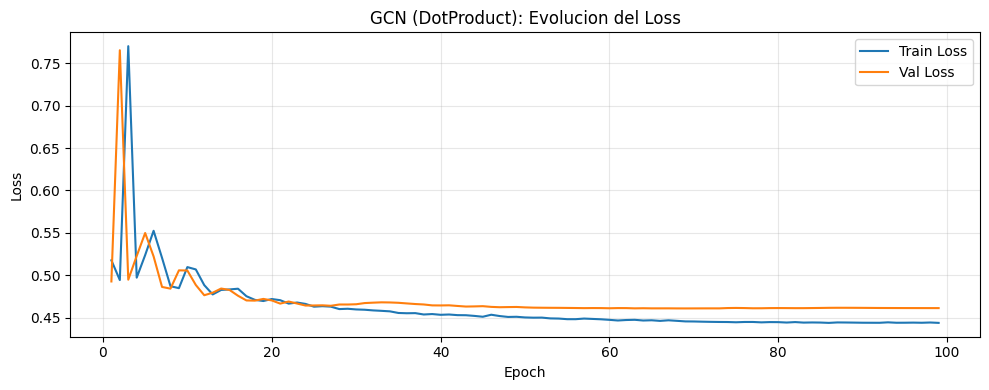

AUC: 0.9250967314553001


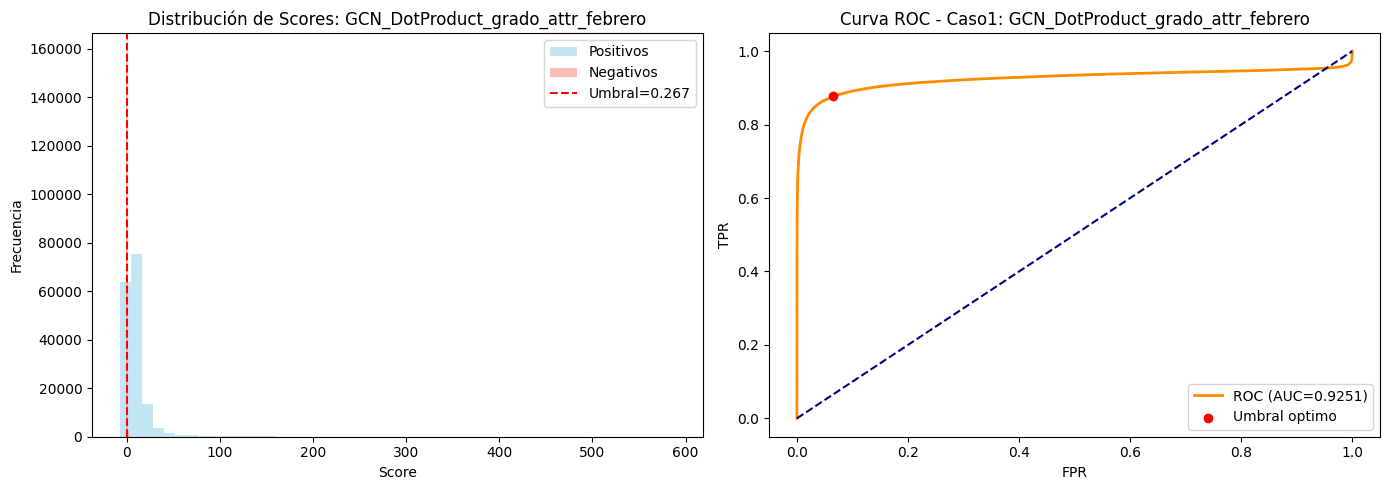

Accuracy: 0.9056 (Threshold: 0.27)


Training model: GraphSAGE [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=19.6474  val=19.7744
  Epoch  10: train=0.7072  val=0.6983
  Epoch  20: train=0.6982  val=0.6981
  Epoch  30: train=0.6962  val=0.6967
  Epoch  40: train=0.6945  val=0.6960
  Epoch  50: train=0.6929  val=0.6924
  Epoch  60: train=0.6870  val=0.6868
  Epoch  70: train=0.6714  val=0.6763
  Epoch  80: train=0.6615  val=0.6632
  Epoch  90: train=0.6537  val=0.6476
  Epoch 100: train=0.6308  val=0.6236
  Epoch 110: train=0.6103  val=0.5962
  Epoch 120: train=0.5917  val=0.5686
  Epoch 130: train=0.5668  val=0.5640
  Epoch 140: train=0.5558  val=0.5555
  Epoch 150: train=0.5454  val=0.5364
  Epoch 160: train=0.5438  val=0.5356
  Epoch 170: train=0.5414  val=0.5346
  Epoch 180: train=0.5414  val=0.5322
  Epoch 190: train=0.5408  val=0.5313
  Epoch 200: train=0.5398  val=0.5313
  Epoch 210: train=0.5415  val=0.5310
  Epoch 220: train=0.5361  val=0.5309
  Epoch 230: train=0.5373  val=0.5309
  Epoch 240: train=0.5385  val=0.5309
  Epoch 250: train=0.5373  val=0.5309
  Epoch 26

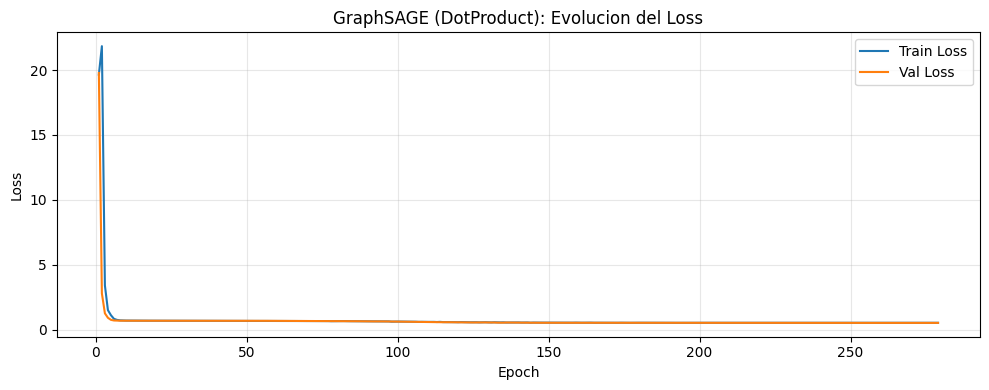

AUC: 0.8601674049401413


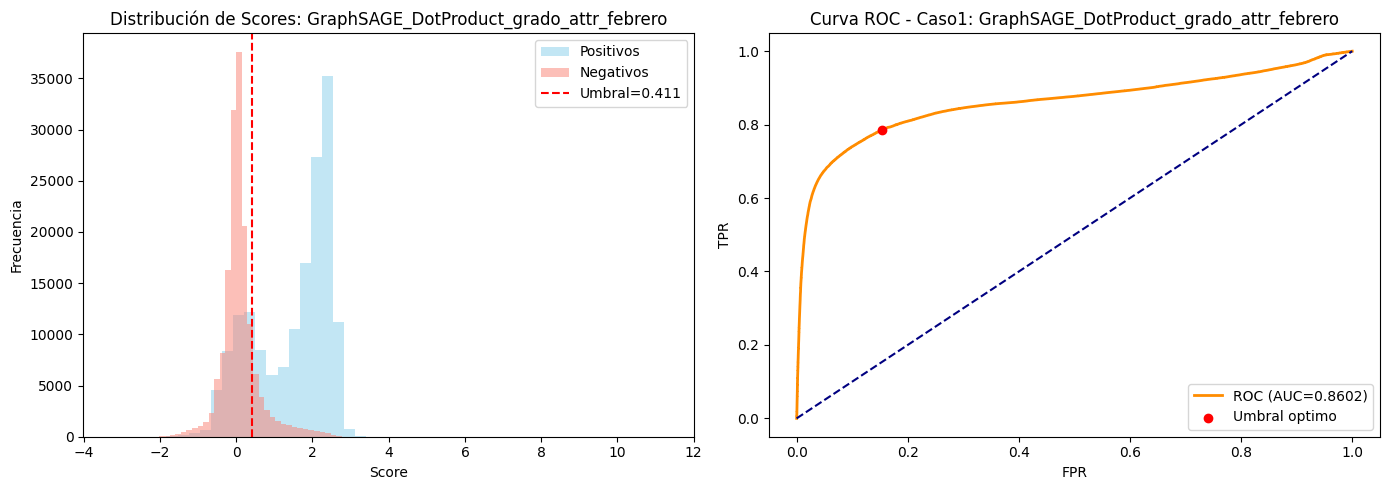

Accuracy: 0.8161 (Threshold: 0.41)


Training model: GAT [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=4.0088  val=0.9401
  Epoch  10: train=0.6552  val=0.6467
  Epoch  20: train=0.5674  val=0.5635
  Epoch  30: train=0.5144  val=0.5239
  Epoch  40: train=0.5005  val=0.5262
  Epoch  50: train=0.4975  val=0.5172
  Epoch  60: train=0.4941  val=0.5069
  Epoch  70: train=0.4910  val=0.5064
  Epoch  80: train=0.4879  val=0.5084
  Epoch  90: train=0.4864  val=0.5043
  Epoch 100: train=0.4841  val=0.5039
  Epoch 110: train=0.4816  val=0.4999
  Epoch 120: train=0.4802  val=0.4993
  Epoch 130: train=0.4778  val=0.4992
  Epoch 140: train=0.4779  val=0.4986
  Epoch 150: train=0.4759  val=0.4977
  Epoch 160: train=0.4774  val=0.4974
  Epoch 170: train=0.4750  val=0.4967
  Epoch 180: train=0.4756  val=0.4962
  Epoch 190: train=0.4746  val=0.4962
  Epoch 200: train=0.4743  val=0.4961
  Epoch 210: train=0.4745  val=0.4961
  Epoch 220: train=0.4747  val=0.4961
  Epoch 230: train=0.4746  val=0.4961
  Early stopping epoch 232. Best val loss: 0.4961
Modelo GAT finalizado en 271.89 segund

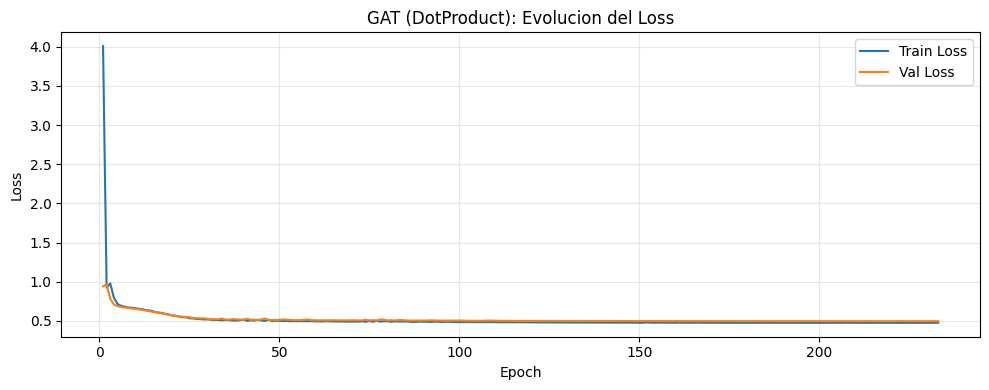

AUC: 0.8847927884864228


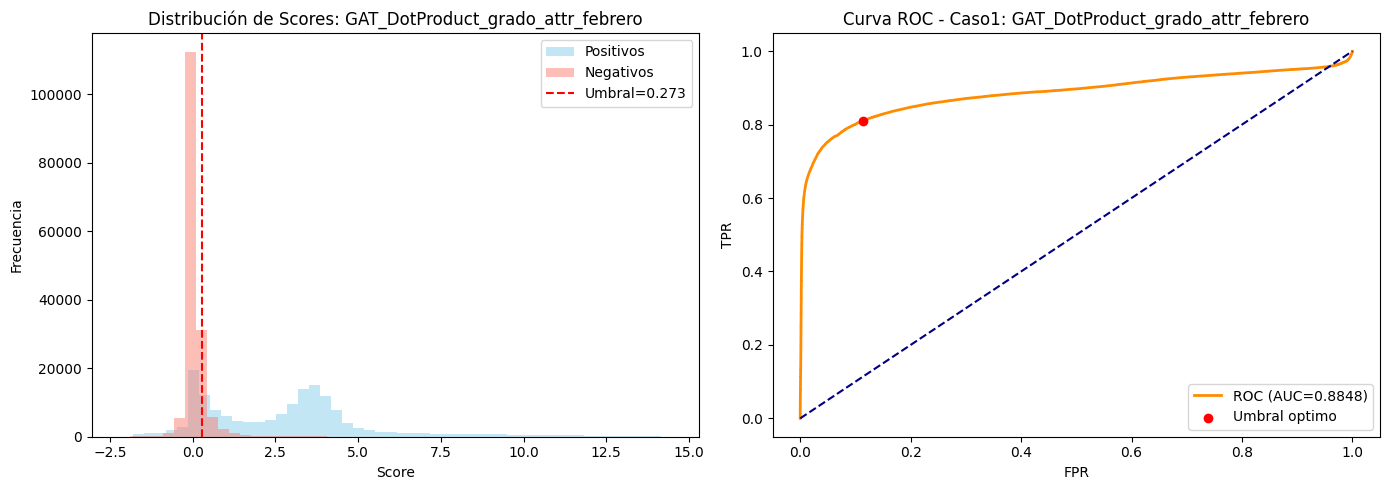

Accuracy: 0.8484 (Threshold: 0.27)



In [ ]:
# attr = 'grado_attr_febrero' (definido arriba)
decoder = 'DotProduct'
in_feats      = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats  = GLOBAL_CONFIG['hidden_dim']
out_feats     = GLOBAL_CONFIG['out_dim']
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso1'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [DotProduct] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=out_feats,
        out_feats_mlp=out_feats_mlp,
    )
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=GLOBAL_CONFIG['lr'],
                                 weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    t0 = time.perf_counter()
    for e in range(GLOBAL_CONFIG['epochs']):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeDotProduct(gnn.train_pos_g, h)
        neg_score = model.decodeDotProduct(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeDotProduct(gnn.test_pos_g, h_eval),
                model.decodeDotProduct(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= GLOBAL_CONFIG['patience']:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break
    tiempo_total = time.perf_counter() - t0
    print(f'Modelo {model_name} finalizado en {tiempo_total:.2f} segundos')

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (DotProduct): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeDotProduct(gnn.test_pos_g, best_h)
        neg_score = model.decodeDotProduct(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_DotProduct_' + attr, 'Caso1')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()

MLP



Training model: GCN [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6835  val=0.5090
  Epoch  10: train=0.3889  val=0.3807
  Epoch  20: train=0.2223  val=0.2120
  Epoch  30: train=0.2065  val=0.2017
  Epoch  40: train=0.1897  val=0.1876
  Epoch  50: train=0.1810  val=0.1838
  Epoch  60: train=0.1747  val=0.1800
  Epoch  70: train=0.1703  val=0.1752
  Epoch  80: train=0.1656  val=0.1711
  Epoch  90: train=0.1632  val=0.1682
  Epoch 100: train=0.1618  val=0.1655
  Epoch 110: train=0.1597  val=0.1637
  Epoch 120: train=0.1580  val=0.1645
  Epoch 130: train=0.1564  val=0.1625
  Epoch 140: train=0.1559  val=0.1628
  Epoch 150: train=0.1558  val=0.1621
  Epoch 160: train=0.1559  val=0.1624
  Early stopping epoch 162. Best val loss: 0.1618
Modelo GCN finalizado en 333.28 segundos


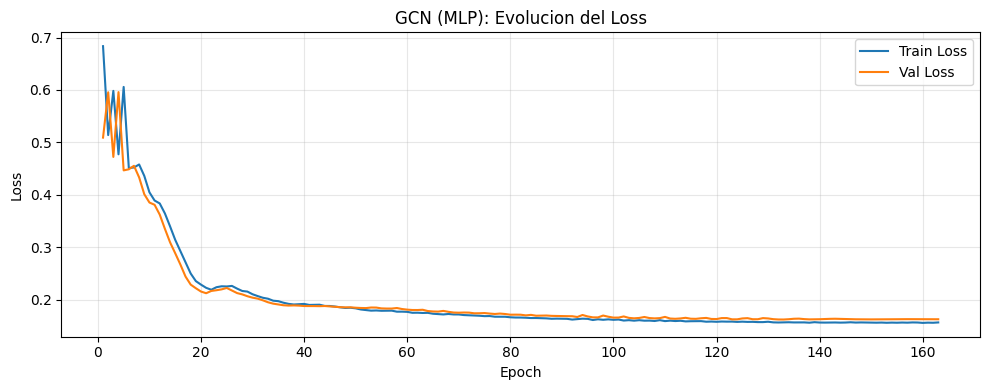

AUC: 0.9832937561943467


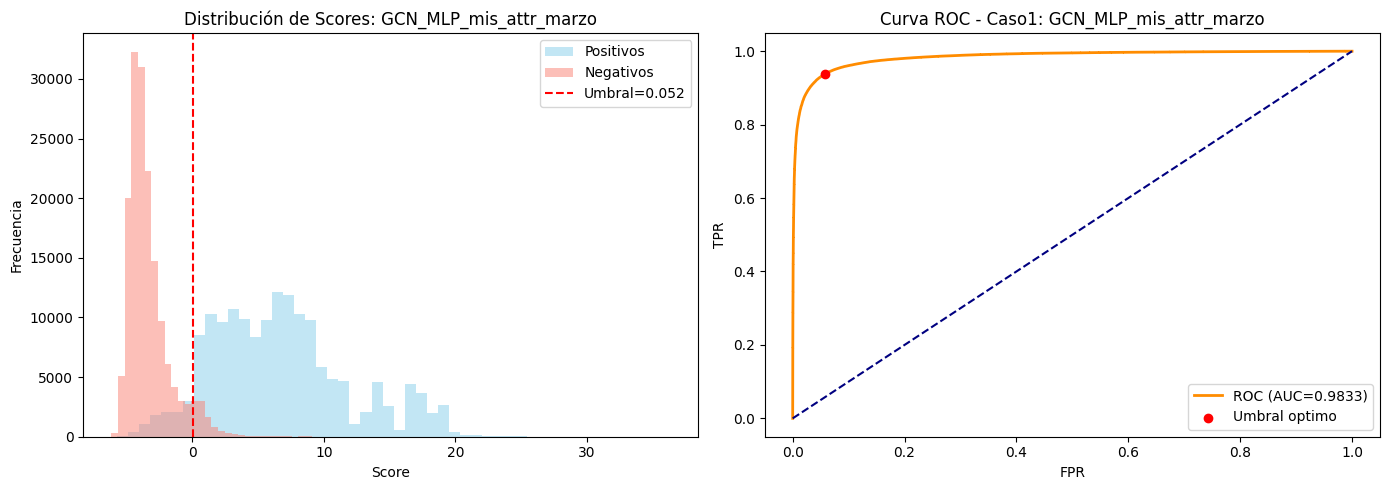

Accuracy: 0.9401 (Threshold: 0.05)


Training model: GraphSAGE [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.7141  val=0.8952
  Epoch  10: train=0.4895  val=0.4002
  Epoch  20: train=0.3809  val=0.3773
  Epoch  30: train=0.2940  val=0.2990
  Epoch  40: train=0.2196  val=0.2243
  Epoch  50: train=0.1886  val=0.2187
  Epoch  60: train=0.1770  val=0.1924
  Epoch  70: train=0.1662  val=0.1866
  Epoch  80: train=0.1626  val=0.1857
  Epoch  90: train=0.1609  val=0.1844
  Epoch 100: train=0.1562  val=0.1820
  Epoch 110: train=0.1538  val=0.1817
  Epoch 120: train=0.1511  val=0.1799
  Epoch 130: train=0.1502  val=0.1798
  Epoch 140: train=0.1504  val=0.1799
  Epoch 150: train=0.1496  val=0.1793
  Epoch 160: train=0.1492  val=0.1794
  Epoch 170: train=0.1497  val=0.1789
  Epoch 180: train=0.1495  val=0.1791
  Epoch 190: train=0.1500  val=0.1792
  Epoch 200: train=0.1493  val=0.1792
  Early stopping epoch 201. Best val loss: 0.1789
Modelo GraphSAGE finalizado en 422.84 segundos


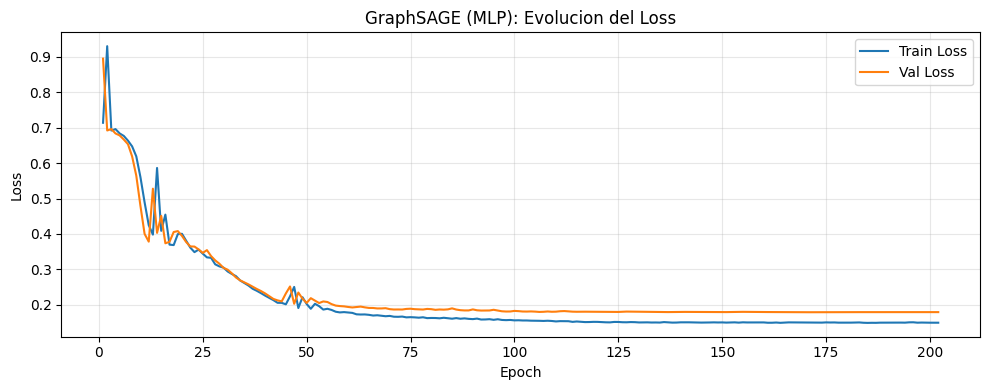

AUC: 0.9815262014205064


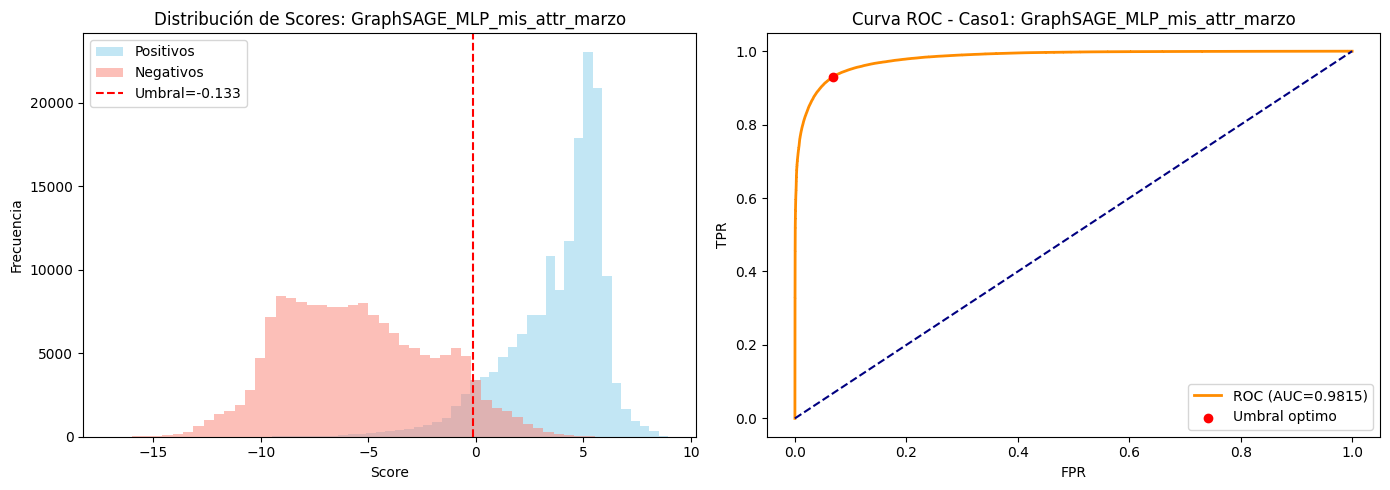

Accuracy: 0.9309 (Threshold: -0.13)


Training model: GAT [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6982  val=0.7167
  Epoch  10: train=0.5483  val=0.6324
  Epoch  20: train=0.5584  val=0.5938
  Epoch  30: train=0.4473  val=0.5105
  Epoch  40: train=0.3803  val=0.4510
  Epoch  50: train=0.3400  val=0.3726
  Epoch  60: train=0.2679  val=0.2917
  Epoch  70: train=0.2415  val=0.3240
  Epoch  80: train=0.2319  val=0.2789
  Epoch  90: train=0.2253  val=0.2521
  Epoch 100: train=0.2248  val=0.2499
  Epoch 110: train=0.2230  val=0.2452
  Early stopping epoch 112. Best val loss: 0.2414
Modelo GAT finalizado en 293.52 segundos


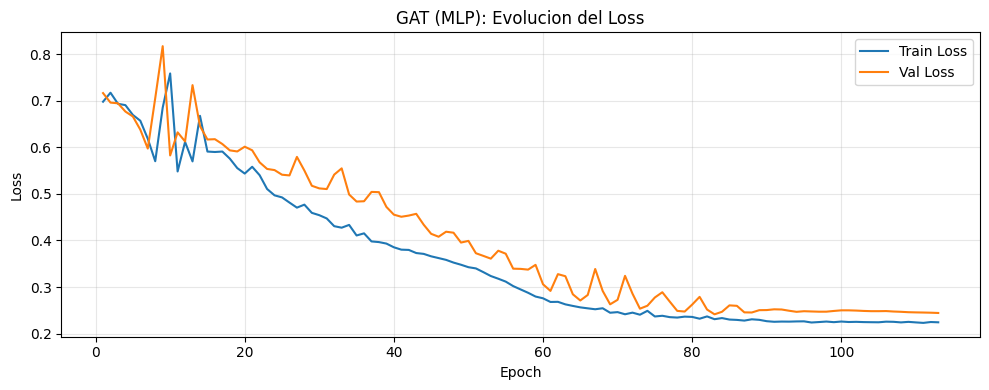

AUC: 0.9633751702786377


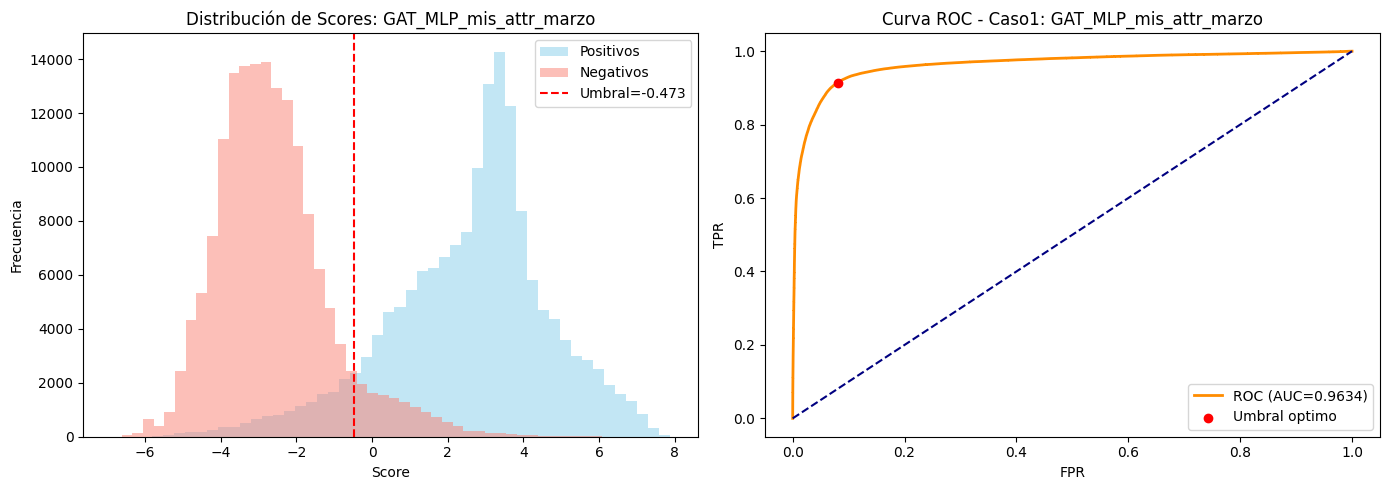

Accuracy: 0.9169 (Threshold: -0.47)



In [ ]:
# attr = 'grado_attr_febrero' (definido arriba)
decoder = 'MLP'
in_feats      = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats  = GLOBAL_CONFIG['hidden_dim']
out_feats     = GLOBAL_CONFIG['out_dim']
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso1'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [MLP] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=out_feats,
        out_feats_mlp=out_feats_mlp,
    )
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=GLOBAL_CONFIG['lr'],
                                 weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    t0 = time.perf_counter()
    for e in range(GLOBAL_CONFIG['epochs']):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeMLP(gnn.train_pos_g, h)
        neg_score = model.decodeMLP(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeMLP(gnn.test_pos_g, h_eval),
                model.decodeMLP(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= GLOBAL_CONFIG['patience']:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break
    tiempo_total = time.perf_counter() - t0
    print(f'Modelo {model_name} finalizado en {tiempo_total:.2f} segundos')

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (MLP): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeMLP(gnn.test_pos_g, best_h)
        neg_score = model.decodeMLP(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_MLP_' + attr, 'Caso1')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()

### Caso 2: Predicción de enlaces utilizando grafo con atributos provenientes de estudios pre

In [ ]:
models = {
    'GCN': GCN3L,
    'GraphSAGE': GraphSAGE3L,
    'GAT': GAT3L,
}
# models = {
#     'GCN': GCN2L,
#     'GraphSAGE': GraphSAGE2L,
#     'GAT': GAT2L,
# }

# CASO 2: Grafo 2022 con atributos de nodos del paper
# ---------------------------------------
attr = '2022_attr'
INTERNETGRAPH_FILE = '/media/vale/KINGSTON/TESIS/InternetGNNData2022/caida/caida.bin'

gnn = GNN(debug=True)
graphs, _ = dgl.load_graphs(INTERNETGRAPH_FILE)
gnn.dgl_graph = graphs[0]
print(f'Grafo 2022: {gnn.dgl_graph.num_nodes():,} nodos, {gnn.dgl_graph.num_edges():,} aristas')
print(f'Dimensión de features: {gnn.dgl_graph.ndata["feat"].shape[1]}')

gnn.split_edges_link_prediction(0.8)


Grafo 2022: 46,235 nodos, 433,979 aristas
Dimensión de features: 72
[split_basic] +pos train=347183  +pos test=86796
[split_basic] -neg train=347183 -neg test=86796


DotProduct


Training model: GCN [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6914  val=0.6954
  Epoch  10: train=0.5424  val=0.5982
  Epoch  20: train=0.5012  val=0.5224
  Epoch  30: train=0.4744  val=0.5112
  Epoch  40: train=0.4695  val=0.5070
  Epoch  50: train=0.4669  val=0.5033
  Epoch  60: train=0.4647  val=0.5000
  Epoch  70: train=0.4636  val=0.4977
  Epoch  80: train=0.4626  val=0.4958
  Epoch  90: train=0.4611  val=0.4940
  Epoch 100: train=0.4606  val=0.4918
  Epoch 110: train=0.4610  val=0.4911
  Epoch 120: train=0.4594  val=0.4892
  Epoch 130: train=0.4589  val=0.4885
  Epoch 140: train=0.4590  val=0.4888
  Epoch 150: train=0.4591  val=0.4886
  Epoch 160: train=0.4586  val=0.4889
  Early stopping epoch 160. Best val loss: 0.4885
Modelo GCN finalizado en 48.38 segundos


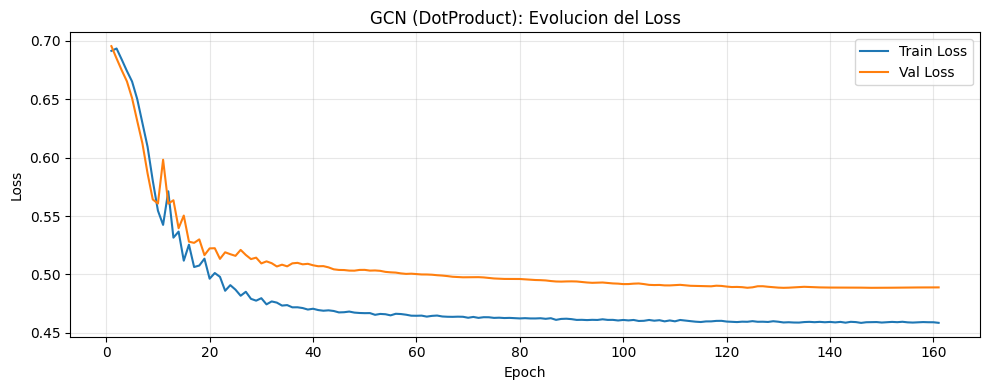

AUC: 0.8668331701782849


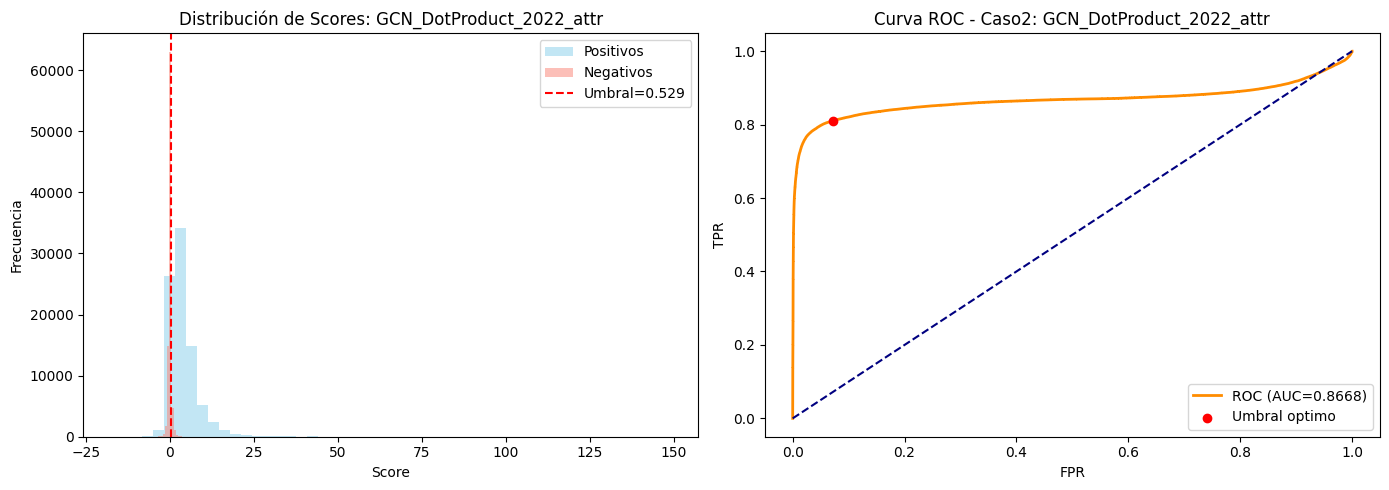

Accuracy: 0.8693 (Threshold: 0.53)


Training model: GraphSAGE [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=45.8474  val=13.9042
  Epoch  10: train=0.7101  val=0.6966
  Epoch  20: train=0.6963  val=0.6945
  Epoch  30: train=0.6845  val=0.6760
  Epoch  40: train=0.6579  val=0.6446
  Epoch  50: train=0.6313  val=0.6013
  Epoch  60: train=0.6135  val=0.5571
  Epoch  70: train=0.5937  val=0.5250
  Epoch  80: train=0.5605  val=0.5230
  Epoch  90: train=0.5597  val=0.5070
  Epoch 100: train=0.5522  val=0.4941
  Epoch 110: train=0.5358  val=0.4948
  Epoch 120: train=0.5419  val=0.4924
  Epoch 130: train=0.5305  val=0.4924
  Epoch 140: train=0.5284  val=0.4909
  Epoch 150: train=0.5358  val=0.4906
  Epoch 160: train=0.5400  val=0.4907
  Epoch 170: train=0.5309  val=0.4907
  Early stopping epoch 177. Best val loss: 0.4905
Modelo GraphSAGE finalizado en 58.46 segundos


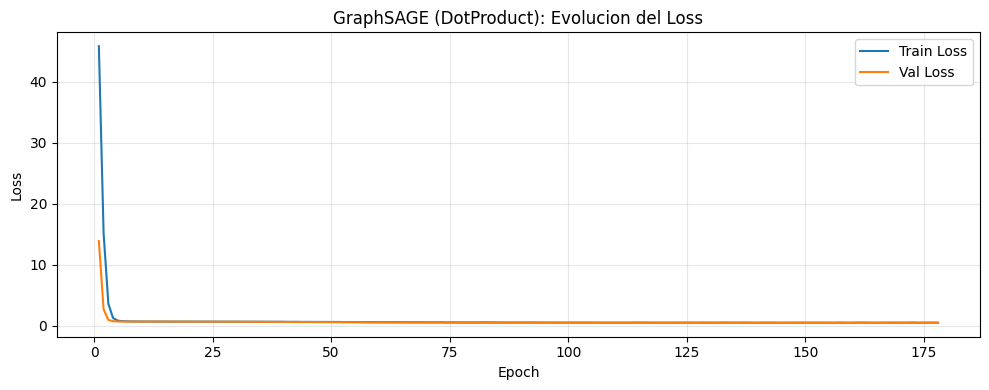

AUC: 0.8882229543136279


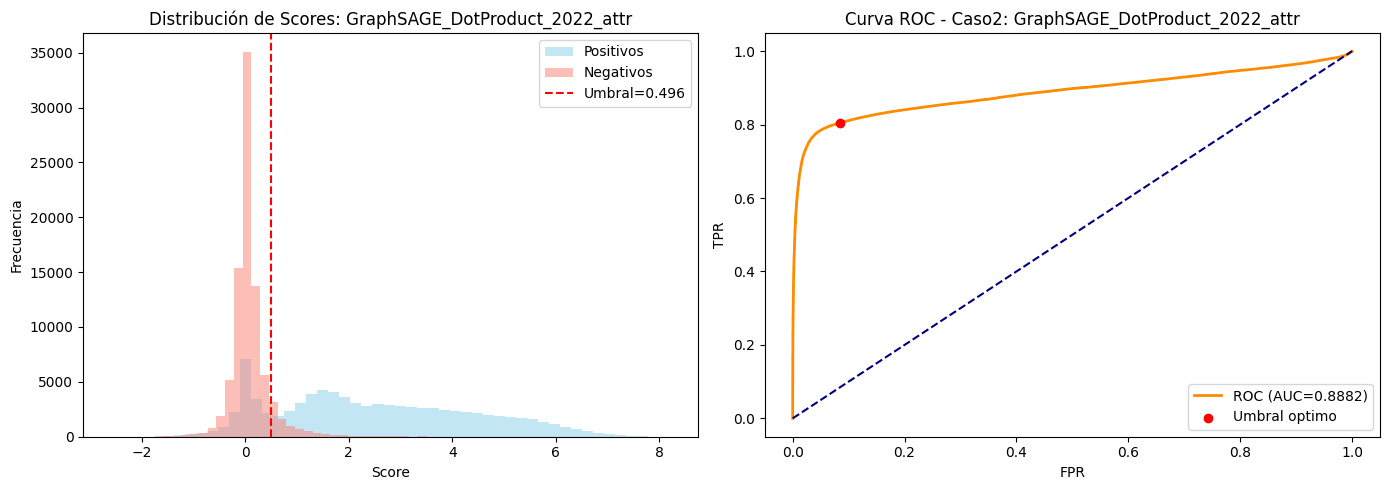

Accuracy: 0.8603 (Threshold: 0.50)


Training model: GAT [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=2.8858  val=1.2424
  Epoch  10: train=0.6871  val=0.6864
  Epoch  20: train=0.6347  val=0.6228
  Epoch  30: train=0.5559  val=0.5734
  Epoch  40: train=0.5252  val=0.5673
  Epoch  50: train=0.5074  val=0.5221
  Epoch  60: train=0.5239  val=0.5614
  Epoch  70: train=0.4905  val=0.5324
  Epoch  80: train=0.4913  val=0.5130
  Epoch  90: train=0.4860  val=0.5187
  Epoch 100: train=0.4830  val=0.5112
  Epoch 110: train=0.4840  val=0.5096
  Early stopping epoch 116. Best val loss: 0.5055
Modelo GAT finalizado en 76.49 segundos


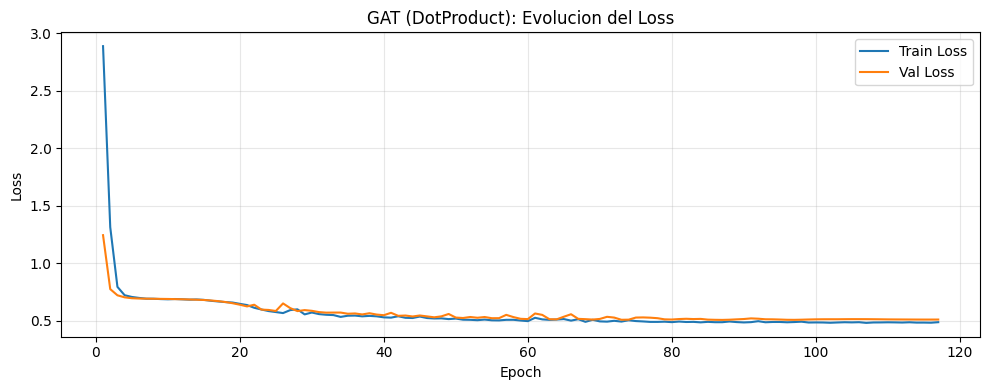

AUC: 0.8690226558256497


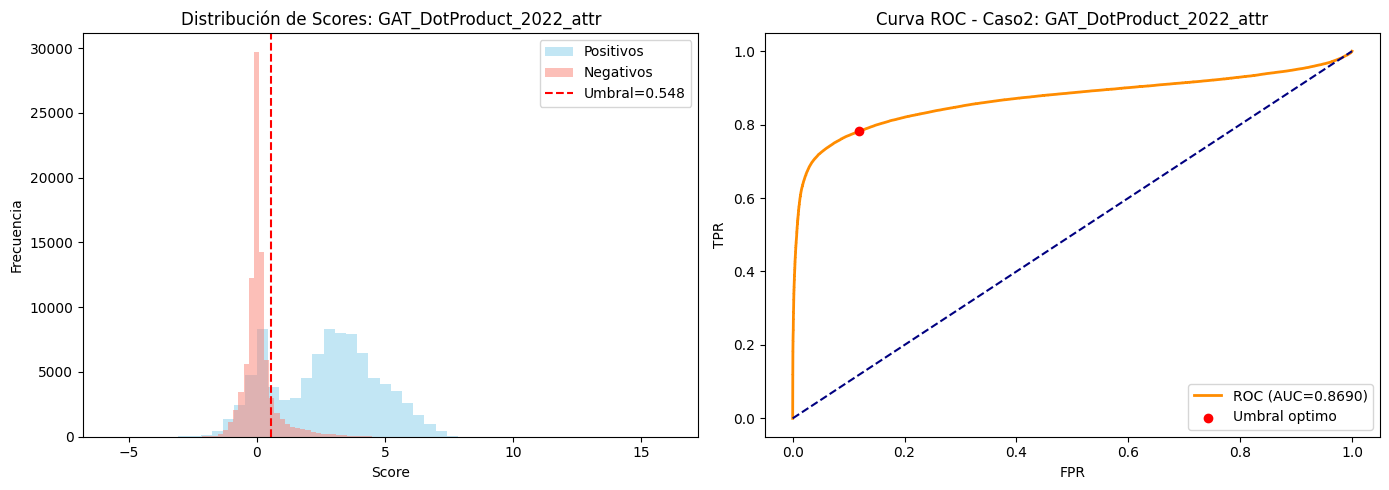

Accuracy: 0.8317 (Threshold: 0.55)



In [ ]:
# attr = '2022_attr' (definido arriba)
decoder = 'DotProduct'
in_feats      = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats  = GLOBAL_CONFIG['hidden_dim']
out_feats     = GLOBAL_CONFIG['out_dim']
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso2'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [DotProduct] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=out_feats,
        out_feats_mlp=out_feats_mlp,
    )
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=GLOBAL_CONFIG['lr'],
                                 weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    t0 = time.perf_counter()
    for e in range(GLOBAL_CONFIG['epochs']):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeDotProduct(gnn.train_pos_g, h)
        neg_score = model.decodeDotProduct(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeDotProduct(gnn.test_pos_g, h_eval),
                model.decodeDotProduct(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= GLOBAL_CONFIG['patience']:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break
    tiempo_total = time.perf_counter() - t0
    print(f'Modelo {model_name} finalizado en {tiempo_total:.2f} segundos')

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (DotProduct): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeDotProduct(gnn.test_pos_g, best_h)
        neg_score = model.decodeDotProduct(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_DotProduct_' + attr, 'Caso2')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()

MLP


Training model: GCN [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6948  val=0.6826
  Epoch  10: train=0.4690  val=0.4319
  Epoch  20: train=0.2829  val=0.3002
  Epoch  30: train=0.2492  val=0.2623
  Epoch  40: train=0.2207  val=0.2475
  Epoch  50: train=0.2035  val=0.2298
  Epoch  60: train=0.1920  val=0.2209
  Epoch  70: train=0.1834  val=0.2105
  Epoch  80: train=0.1799  val=0.2123
  Epoch  90: train=0.1766  val=0.2056
  Epoch 100: train=0.1743  val=0.2062
  Epoch 110: train=0.1736  val=0.2052
  Epoch 120: train=0.1740  val=0.2037
  Epoch 130: train=0.1720  val=0.2038
  Epoch 140: train=0.1719  val=0.2034
  Epoch 150: train=0.1715  val=0.2031
  Early stopping epoch 152. Best val loss: 0.2027
Modelo GCN finalizado en 161.21 segundos


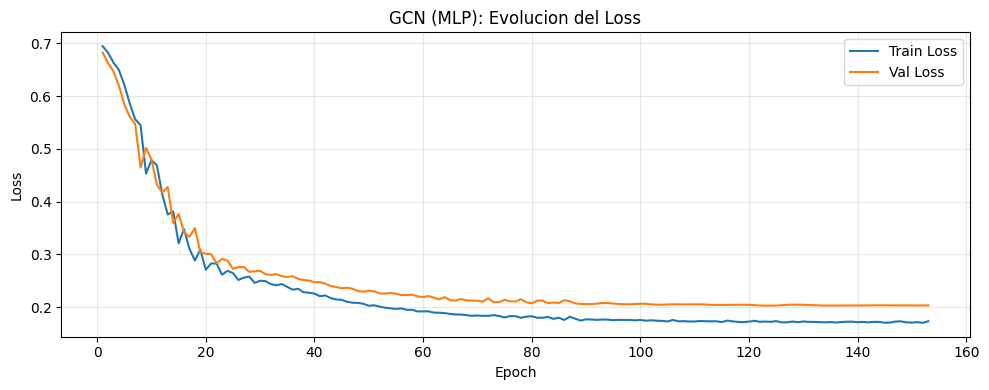

AUC: 0.9748545387317131


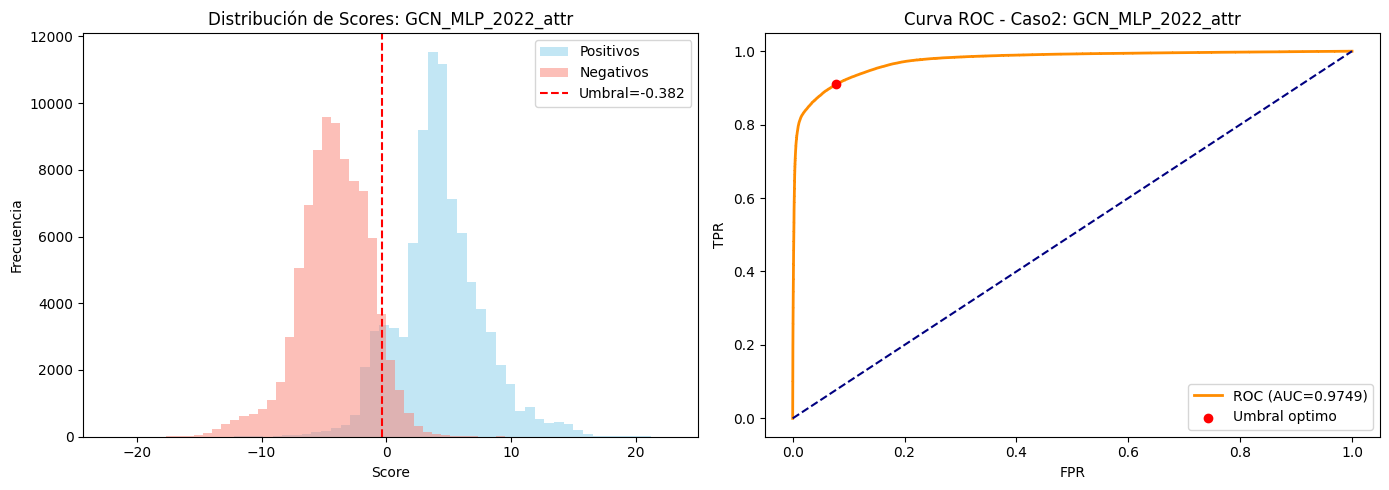

Accuracy: 0.9161 (Threshold: -0.38)


Training model: GraphSAGE [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.7568  val=1.3539
  Epoch  10: train=0.5831  val=0.4651
  Epoch  20: train=0.2468  val=0.2037
  Epoch  30: train=0.1943  val=0.1811
  Epoch  40: train=0.1709  val=0.1652
  Epoch  50: train=0.1540  val=0.1582
  Epoch  60: train=0.1455  val=0.1504
  Epoch  70: train=0.1378  val=0.1458
  Epoch  80: train=0.1316  val=0.1438
  Epoch  90: train=0.1265  val=0.1415
  Epoch 100: train=0.1260  val=0.1400
  Epoch 110: train=0.1228  val=0.1396
  Epoch 120: train=0.1210  val=0.1387
  Epoch 130: train=0.1206  val=0.1391
  Early stopping epoch 134. Best val loss: 0.1379
Modelo GraphSAGE finalizado en 144.10 segundos


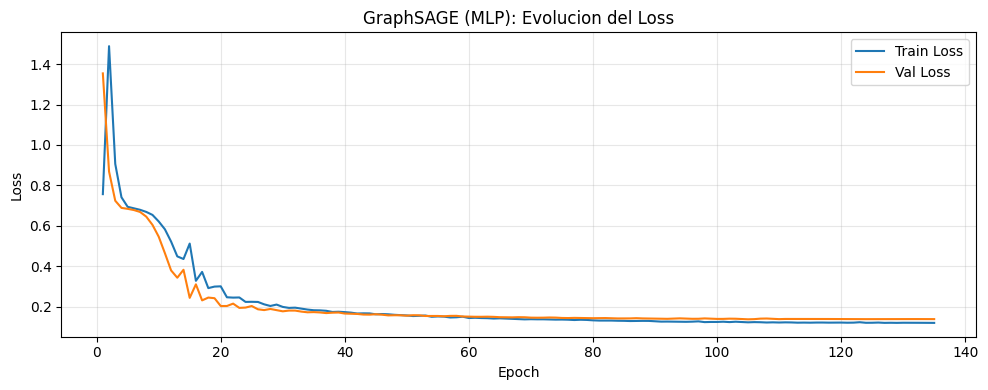

AUC: 0.9879211476722543


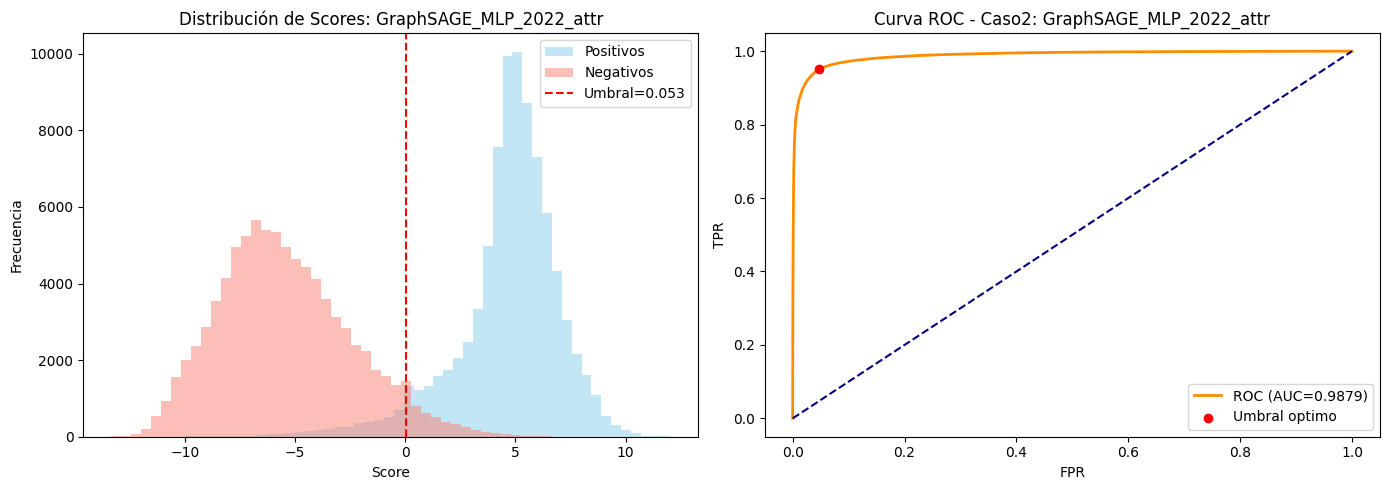

Accuracy: 0.9517 (Threshold: 0.05)


Training model: GAT [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6981  val=0.7023
  Epoch  10: train=0.6351  val=0.5586
  Epoch  20: train=0.4265  val=0.4180
  Epoch  30: train=0.3924  val=0.4279
  Epoch  40: train=0.3735  val=0.4035
  Epoch  50: train=0.3868  val=0.4379
  Epoch  60: train=0.3657  val=0.4021
  Early stopping epoch 65. Best val loss: 0.3976
Modelo GAT finalizado en 88.47 segundos


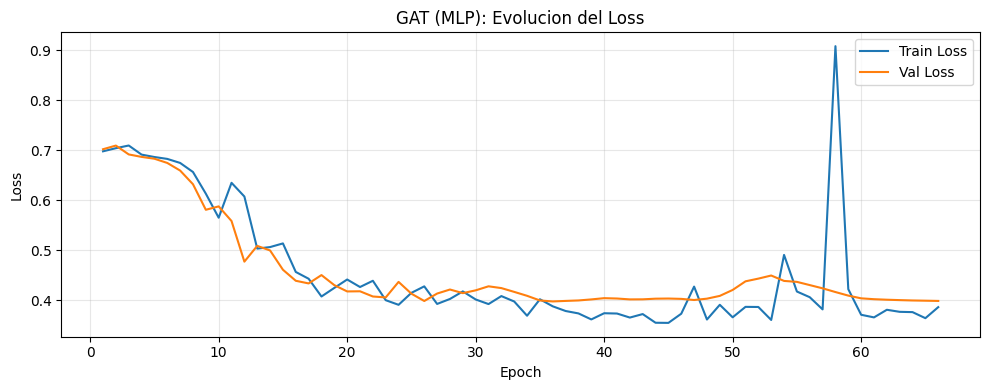

AUC: 0.8984240603289393


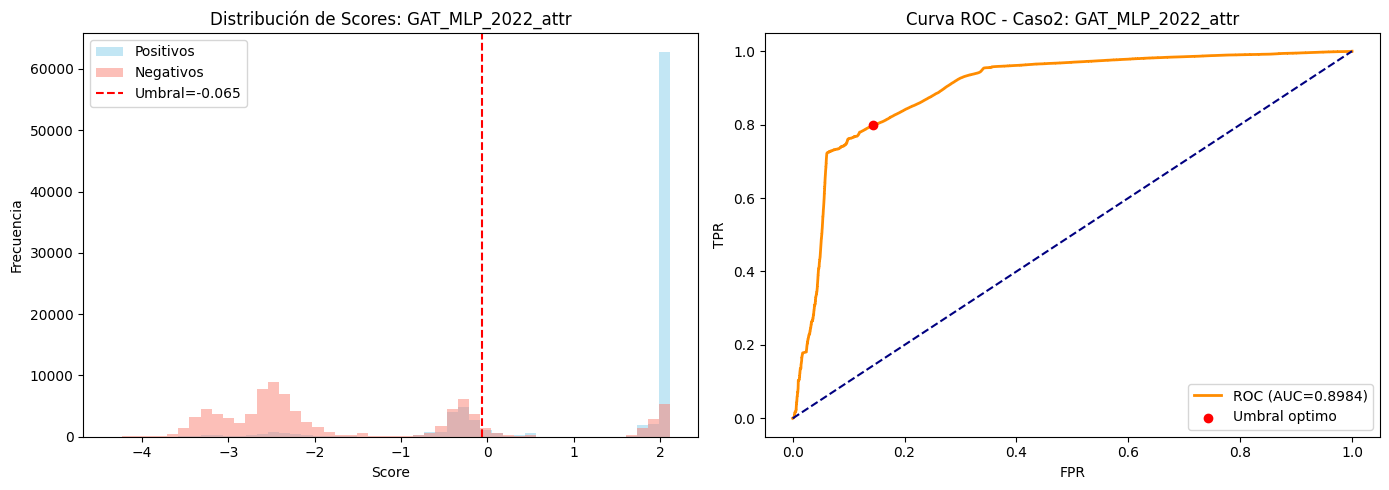

Accuracy: 0.8270 (Threshold: -0.06)



In [ ]:
# attr = '2022_attr' (definido arriba)
decoder = 'MLP'
in_feats      = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats  = GLOBAL_CONFIG['hidden_dim']
out_feats     = GLOBAL_CONFIG['out_dim']
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso2'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [MLP] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=out_feats,
        out_feats_mlp=out_feats_mlp,
    )
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=GLOBAL_CONFIG['lr'],
                                 weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    t0 = time.perf_counter()
    for e in range(GLOBAL_CONFIG['epochs']):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeMLP(gnn.train_pos_g, h)
        neg_score = model.decodeMLP(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeMLP(gnn.test_pos_g, h_eval),
                model.decodeMLP(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= GLOBAL_CONFIG['patience']:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break
    tiempo_total = time.perf_counter() - t0
    print(f'Modelo {model_name} finalizado en {tiempo_total:.2f} segundos')

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (MLP): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeMLP(gnn.test_pos_g, best_h)
        neg_score = model.decodeMLP(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_MLP_' + attr, 'Caso2')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()

### Caso 3: Predicción del grado de los nodos utilizando grafo con atributos extraídos de Peering

In [ ]:
models = {
    'GCN': GCN3L,
    'GraphSAGE': GraphSAGE3L,
    'GAT': GAT3L,
}

# models = {
#     'GCN': GCN2L,
#     'GraphSAGE': GraphSAGE2L,
#     'GAT': GAT2L,
# }


# CASO 3: Grafo con atributos de nodos extraídos de PeeringDB
# ---------------------------------------
attr = 'out_degree'

# 1. Cargar datos con el nuevo formato (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))


gnn.split_graph_nodes(train_size=0.8)


g0 = gnn.dgl_graph

Grafo cargado: 79504 nodos, 807496 aristas
Aristas en ambos sentidos: True
Dimensión de entrada (in_feats): 72
Edge features: 1 dim
Train nodes: 63603, Test nodes: 15901


In [ ]:
degrees = gnn.dgl_graph.out_degrees(gnn.dgl_graph.nodes()).float().unsqueeze(1)

# Transformación logarítmica
deg_log = torch.log1p(degrees)  # log(1 + x)

# Min-max normalization después del log
min_val = deg_log.min()
max_val = deg_log.max()
deg_log_norm = (deg_log - min_val) / (max_val - min_val + 1e-8)

gnn.dgl_graph.ndata['out_degree'] = deg_log_norm



encode: GNN

Split => Train: 50883 | Val: 12720 | Test: 15901

Training model: GCN ----------------------------------------
  Epoch   0: train=0.503986  val=0.504312
  Epoch  10: train=0.076927  val=0.076545
  Epoch  20: train=0.057148  val=0.057205
  Epoch  30: train=0.041114  val=0.041114
  Epoch  40: train=0.028407  val=0.028530
  Epoch  50: train=0.030481  val=0.030786
  Epoch  60: train=0.030183  val=0.030010
  Epoch  70: train=0.025971  val=0.026059
  Epoch  80: train=0.025098  val=0.025215
  Epoch  90: train=0.025041  val=0.025152
  Epoch 100: train=0.024753  val=0.024968
  Epoch 110: train=0.024688  val=0.024903
  Epoch 120: train=0.024659  val=0.024867
  Epoch 130: train=0.024553  val=0.024772
  Epoch 140: train=0.024502  val=0.024750
  Epoch 150: train=0.024495  val=0.024739
  Epoch 160: train=0.024471  val=0.024730
  Epoch 170: train=0.024479  val=0.024704
  Epoch 180: train=0.024469  val=0.024699
  Epoch 190: train=0.024471  val=0.024703
  Early stopping epoch 197. Best val MAE: 0.02469

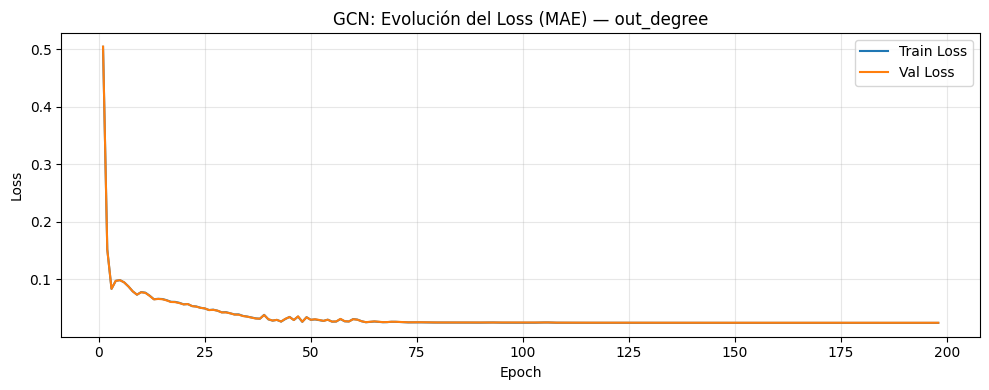

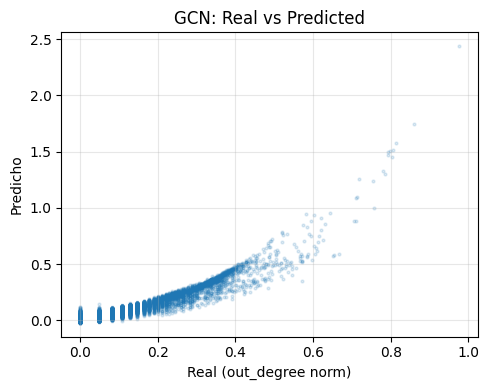


  [Métricas GCN]
  Best Val MAE : 0.024690
  Test MAE     : 0.023658
  Test R²      : 0.860671
  Guardado: embeddings_ribs_GCN_out_degree.pt


Training model: GraphSAGE ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=5.394577  val=5.397335
  Epoch  10: train=0.073222  val=0.073108
  Epoch  20: train=0.067843  val=0.067723
  Epoch  30: train=0.066530  val=0.066374
  Epoch  40: train=0.065736  val=0.065576
  Epoch  50: train=0.065312  val=0.065113
  Epoch  60: train=0.062354  val=0.062108
  Epoch  70: train=0.064935  val=0.064654
  Epoch  80: train=0.065137  val=0.064795
  Epoch  90: train=0.065859  val=0.065514
  Early stopping epoch 97. Best val MAE: 0.060206
Modelo GraphSAGE finalizado en 50.06 segundos


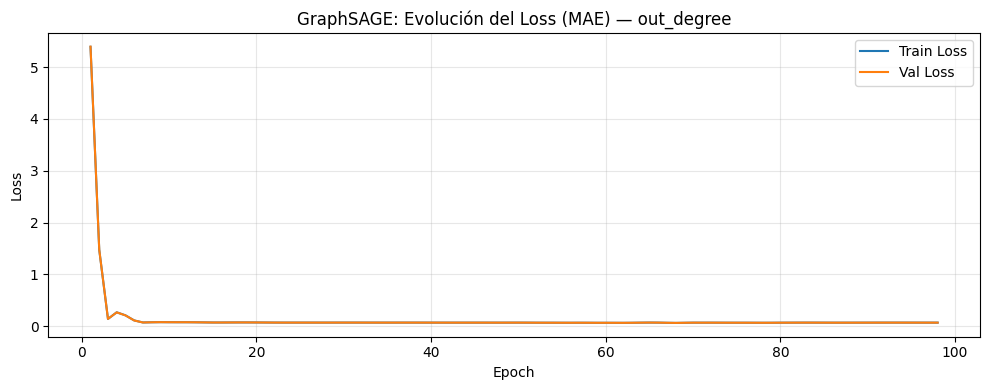

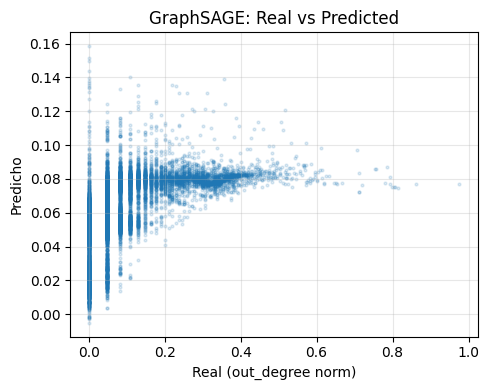


  [Métricas GraphSAGE]
  Best Val MAE : 0.060206
  Test MAE     : 0.060294
  Test R²      : 0.136781
  Guardado: embeddings_ribs_GraphSAGE_out_degree.pt


Training model: GAT ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=1.564244  val=1.561790
  Epoch  10: train=0.067495  val=0.067321
  Epoch  20: train=0.065562  val=0.065523
  Epoch  30: train=0.063914  val=0.063912
  Epoch  40: train=0.066196  val=0.066200
  Epoch  50: train=0.066500  val=0.066473
  Epoch  60: train=0.065103  val=0.065071
  Early stopping epoch 67. Best val MAE: 0.060229
Modelo GAT finalizado en 74.82 segundos


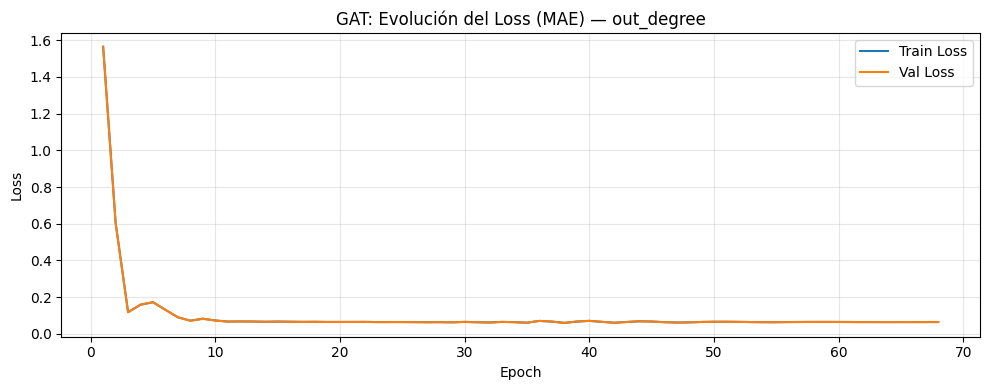

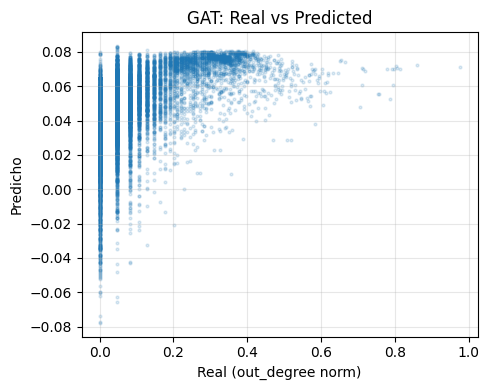


  [Métricas GAT]
  Best Val MAE : 0.060229
  Test MAE     : 0.060227
  Test R²      : 0.069330
  Guardado: embeddings_ribs_GAT_out_degree.pt



In [ ]:
attr = 'out_degree'
features = gnn.dgl_graph.ndata['feat']
labels   = gnn.dgl_graph.ndata['out_degree']

# Split: 64% train / 16% val / 20% test
train_mask_orig     = gnn.dgl_graph.ndata['train_mask']
test_mask           = gnn.dgl_graph.ndata['test_mask']
train_indices       = torch.where(train_mask_orig)[0]
g_seed              = torch.Generator().manual_seed(42)
perm                = torch.randperm(len(train_indices), generator=g_seed)
n_val               = int(0.2 * len(train_indices))
val_indices         = train_indices[perm[:n_val]]
train_indices_final = train_indices[perm[n_val:]]
val_mask  = torch.zeros(gnn.dgl_graph.num_nodes(), dtype=torch.bool)
val_mask[val_indices] = True
train_mask = torch.zeros(gnn.dgl_graph.num_nodes(), dtype=torch.bool)
train_mask[train_indices_final] = True
print(f'Split => Train: {train_mask.sum()} | Val: {val_mask.sum()} | Test: {test_mask.sum()}')

in_feats      = features.shape[1]
hidden_feats  = GLOBAL_CONFIG['hidden_dim']
out_feats     = GLOBAL_CONFIG['out_dim']
out_feats_mlp = 1
save_dir      = data_path + 'results/EnfoquePorPartes/Caso3'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=out_feats,
        out_feats_mlp=out_feats_mlp,
        edge_dim=1,
    )
    loss_fn   = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=GLOBAL_CONFIG['lr'],
                                 weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss    = float('inf')
    best_state       = None
    patience_counter = 0

    t0 = time.perf_counter()
    for epoch in range(GLOBAL_CONFIG['epochs']):
        model.train()
        pred = model(gnn.dgl_graph, features)
        loss = loss_fn(pred[train_mask], labels[train_mask])
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_eval = model(gnn.dgl_graph, features)
            train_mae = loss_fn(pred_eval[train_mask], labels[train_mask]).item()
            val_mae   = loss_fn(pred_eval[val_mask],   labels[val_mask]).item()
        train_losses.append(train_mae)
        val_losses.append(val_mae)
        scheduler.step(val_mae)

        if epoch % 10 == 0 or epoch == GLOBAL_CONFIG['epochs'] - 1:
            print(f'  Epoch {epoch:3d}: train={train_mae:.6f}  val={val_mae:.6f}')

        if val_mae < best_val_loss:
            best_val_loss    = val_mae
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= GLOBAL_CONFIG['patience']:
            print(f'  Early stopping epoch {epoch}. Best val MAE: {best_val_loss:.6f}')
            break
    tiempo_total = time.perf_counter() - t0
    print(f'Modelo {model_name} finalizado en {tiempo_total:.2f} segundos')

    model.load_state_dict(best_state)
    model.eval()

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name}: Evolución del Loss (MAE) — out_degree',
                        val_losses=val_losses)

    with torch.no_grad():
        pred_final = model(gnn.dgl_graph, features)
        embeddings = model.encode(gnn.dgl_graph, features)

    pred_test   = pred_final[test_mask].cpu().numpy().flatten()
    labels_test = labels[test_mask].cpu().numpy().flatten()
    test_mae    = loss_fn(pred_final[test_mask], labels[test_mask]).item()
    r2          = r2_score(labels_test, pred_test)

    plt.figure(figsize=(5, 4))
    plt.scatter(labels_test, pred_test, alpha=0.15, s=4)
    plt.xlabel('Real (out_degree norm)')
    plt.ylabel('Predicho')
    plt.title(f'{model_name}: Real vs Predicted')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n  [Métricas {model_name}]')
    print(f'  Best Val MAE : {best_val_loss:.6f}')
    print(f'  Test MAE     : {test_mae:.6f}')
    print(f'  Test R²      : {r2:.6f}')

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{model_name}_{attr}.pth')
    torch.save(embeddings,
               f'{save_dir}/embeddings_ribs_{model_name}_{attr}.pt')
    print(f'  Guardado: embeddings_ribs_{model_name}_{attr}.pt')
    print()

ESTADÍSTICAS DEL GRAFO
Número de nodos (ASes): 79,504
Número de aristas: 807,496
Densidad del grafo: 0.000128

Grado de entrada promedio: 10.16
Grado de salida promedio: 10.16
Grado de entrada máximo: 9822
Grado de salida máximo: 9822


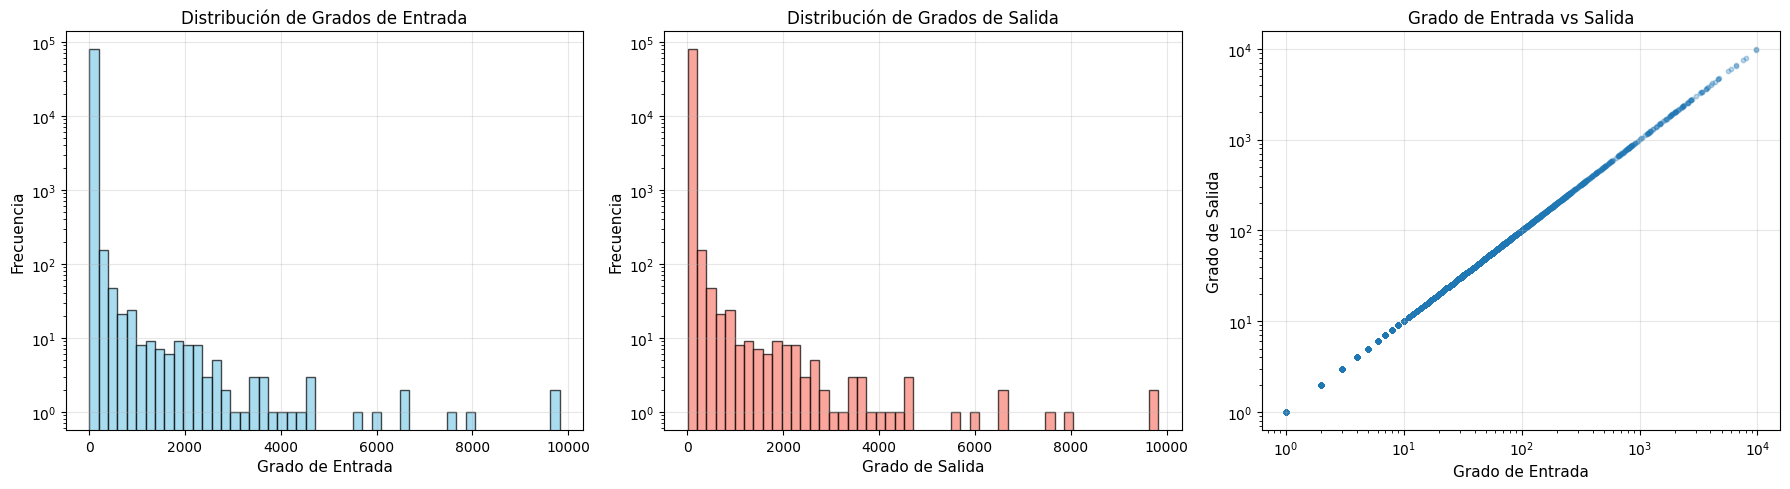

In [ ]:
# Estadísticas del grafo
num_nodes = gnn.dgl_graph.num_nodes()
num_edges = gnn.dgl_graph.num_edges()
in_degrees = gnn.dgl_graph.in_degrees().numpy()
out_degrees = gnn.dgl_graph.out_degrees().numpy()

print("=" * 60)
print("ESTADÍSTICAS DEL GRAFO")
print("=" * 60)
print(f"Número de nodos (ASes): {num_nodes:,}")
print(f"Número de aristas: {num_edges:,}")
print(f"Densidad del grafo: {num_edges / (num_nodes * (num_nodes - 1)):.6f}")
print(f"\nGrado de entrada promedio: {in_degrees.mean():.2f}")
print(f"Grado de salida promedio: {out_degrees.mean():.2f}")
print(f"Grado de entrada máximo: {in_degrees.max()}")
print(f"Grado de salida máximo: {out_degrees.max()}")

# Visualizar distribución de grados
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de grados de entrada
axes[0].hist(in_degrees, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Grado de Entrada', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de Grados de Entrada', fontsize=12)
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Histograma de grados de salida
axes[1].hist(out_degrees, bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Grado de Salida', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución de Grados de Salida', fontsize=12)
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Scatter plot: in-degree vs out-degree
axes[2].scatter(in_degrees, out_degrees, alpha=0.3, s=10)
axes[2].set_xlabel('Grado de Entrada', fontsize=11)
axes[2].set_ylabel('Grado de Salida', fontsize=11)
axes[2].set_title('Grado de Entrada vs Salida', fontsize=12)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Caso 4: Predicción del valor de PageRank utilizando grafo con atributos extraídos de PeeringDB

In [ ]:
models = {
    'GCN': GCN3L,
    'GraphSAGE': GraphSAGE3L,
    'GAT': GAT3L,
}
# models = {
#     'GCN': GCN2L,
#     'GraphSAGE': GraphSAGE2L,
#     'GAT': GAT2L,
# }



attr = 'pagerank'

# Cargar grafo 
# ---------------------- 
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))


gnn.split_graph_nodes(train_size=0.8)


g4 = gnn.dgl_graph
g4


Grafo cargado: 79504 nodos, 807496 aristas
Aristas en ambos sentidos: True
Dimensión de entrada (in_feats): 72
Edge features: 1 dim
Train nodes: 63603, Test nodes: 15901


Graph(num_nodes=79504, num_edges=807496,
      ndata_schemes={'feat': Scheme(shape=(72,), dtype=torch.float32), 'train_mask': Scheme(shape=(), dtype=torch.bool), 'test_mask': Scheme(shape=(), dtype=torch.bool)}
      edata_schemes={'label': Scheme(shape=(), dtype=torch.int64), 'edge_feat': Scheme(shape=(1,), dtype=torch.float32)})

Calculo PageRank

PageRank raw   — min=0.000002  max=0.010573  mean=0.000013
PageRank norm  — min=0.0000  max=1.0000  mean=0.0010


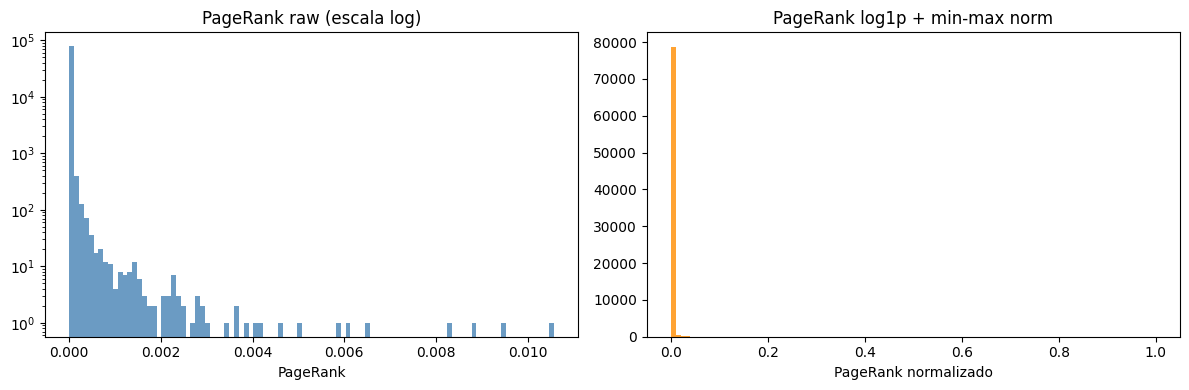

Graph(num_nodes=79504, num_edges=807496,
      ndata_schemes={'feat': Scheme(shape=(72,), dtype=torch.float32), 'train_mask': Scheme(shape=(), dtype=torch.bool), 'test_mask': Scheme(shape=(), dtype=torch.bool), 'pv': Scheme(shape=(), dtype=torch.float32), 'pagerank': Scheme(shape=(1,), dtype=torch.float32), 'pagerank_norm': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={'label': Scheme(shape=(), dtype=torch.int64), 'edge_feat': Scheme(shape=(1,), dtype=torch.float32)})

In [ ]:
N    = gnn.dgl_graph.number_of_nodes()
DAMP = 0.85
K    = 20   # más iteraciones para mejor convergencia

def compute_pagerank(g):
    g.ndata['pv'] = torch.ones(N) / N
    degrees = g.out_degrees(g.nodes()).float()
    degrees = torch.clamp(degrees, min=1)
    for _ in range(K):
        g.ndata['pv'] = g.ndata['pv'] / degrees
        g.update_all(
            message_func=fn.copy_u(u='pv', out='m'),
            reduce_func=fn.sum(msg='m', out='pv'),
        )
        g.ndata['pv'] = (1 - DAMP) / N + DAMP * g.ndata['pv']
    return g.ndata['pv']   # (N,)

pv = compute_pagerank(gnn.dgl_graph)  # (N,) sin unsqueeze todavía
gnn.dgl_graph.ndata['pagerank'] = pv.unsqueeze(1)

# Normalización: log1p primero (aplana la cola power-law) + min-max → [0,1]
pr_log  = torch.log1p(pv)
pr_min  = pr_log.min()
pr_max  = pr_log.max()
pr_norm = (pr_log - pr_min) / (pr_max - pr_min + 1e-12)
gnn.dgl_graph.ndata['pagerank_norm'] = pr_norm.unsqueeze(1)

print(f'PageRank raw   — min={pv.min():.6f}  max={pv.max():.6f}  mean={pv.mean():.6f}')
print(f'PageRank norm  — min={pr_norm.min():.4f}  max={pr_norm.max():.4f}  mean={pr_norm.mean():.4f}')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pv.numpy(), bins=100, log=True, color='steelblue', alpha=0.8)
axes[0].set_title('PageRank raw (escala log)'); axes[0].set_xlabel('PageRank')
axes[1].hist(pr_norm.numpy(), bins=100, color='darkorange', alpha=0.8)
axes[1].set_title('PageRank log1p + min-max norm'); axes[1].set_xlabel('PageRank normalizado')
plt.tight_layout(); plt.show()

gnn.dgl_graph


encode: GNN

Split => Train: 50883 | Val: 12720 | Test: 15901

Training model: GCN ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.527420  val=0.531388
  Epoch  10: train=0.015751  val=0.015778
  Epoch  20: train=0.002607  val=0.002625
  Epoch  30: train=0.001171  val=0.001201
  Epoch  40: train=0.002980  val=0.003001
  Epoch  50: train=0.001956  val=0.001981
  Epoch  60: train=0.001103  val=0.001134
  Epoch  70: train=0.000877  val=0.000907
  Epoch  80: train=0.000791  val=0.000817
  Epoch  90: train=0.000792  val=0.000820
  Epoch 100: train=0.000789  val=0.000817
  Epoch 110: train=0.000791  val=0.000819
  Early stopping epoch 111. Best val MAE: 0.000814
Modelo GCN finalizado en 53.13 segundos


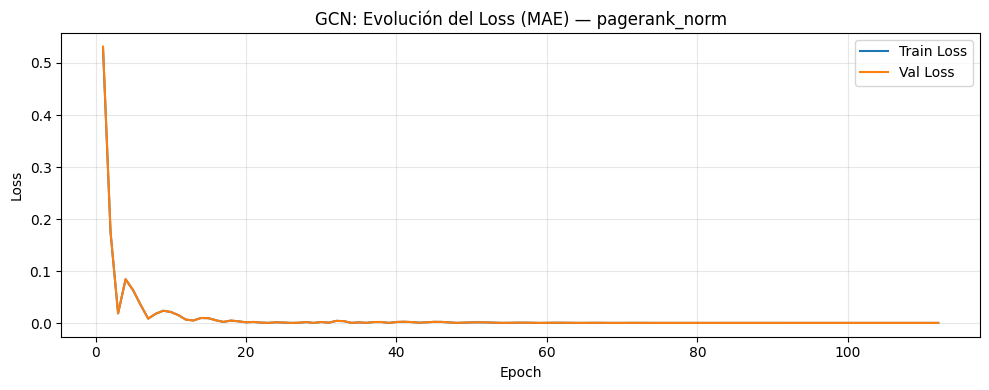

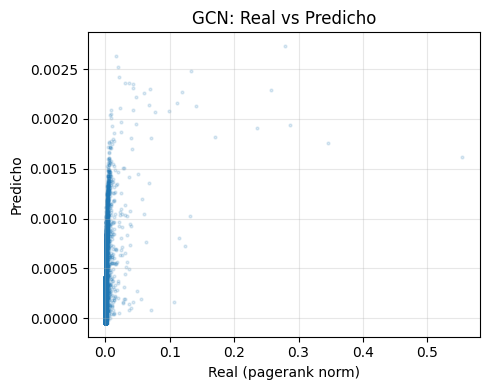


  [Métricas GCN]
  Best Val MAE : 0.000814
  Test MAE     : 0.000729
  Test R²      : 0.012864
  Guardado: embeddings_ribs_GCN_pagerank_norm.pt


Training model: GraphSAGE ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.776182  val=0.772492
  Epoch  10: train=0.010960  val=0.010965
  Epoch  20: train=0.002625  val=0.002648
  Epoch  30: train=0.004367  val=0.004393
  Epoch  40: train=0.001862  val=0.001889
  Epoch  50: train=0.001161  val=0.001186
  Early stopping epoch 57. Best val MAE: 0.000905
Modelo GraphSAGE finalizado en 32.08 segundos


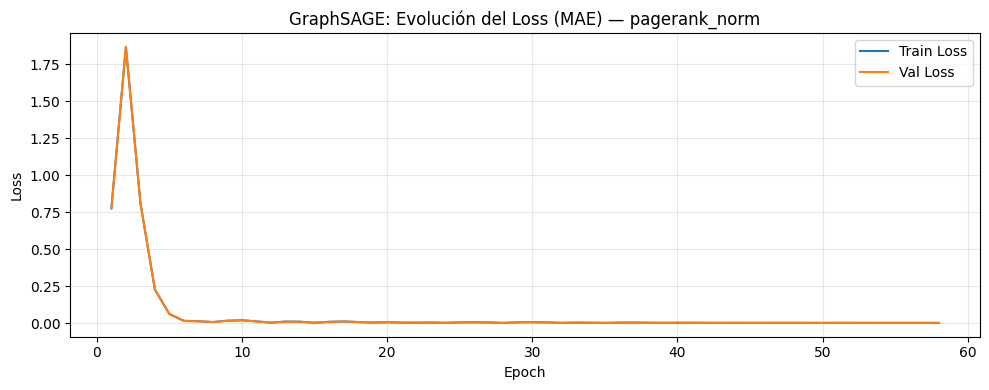

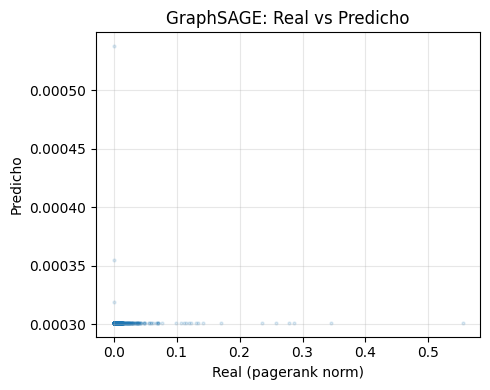


  [Métricas GraphSAGE]
  Best Val MAE : 0.000905
  Test MAE     : 0.000818
  Test R²      : -0.005984
  Guardado: embeddings_ribs_GraphSAGE_pagerank_norm.pt


Training model: GAT ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=1.064258  val=1.064080
  Epoch  10: train=0.004565  val=0.004564
  Epoch  20: train=0.011166  val=0.011193
  Epoch  30: train=0.003966  val=0.003982
  Epoch  40: train=0.001579  val=0.001600
  Epoch  50: train=0.000969  val=0.000994
  Epoch  60: train=0.001399  val=0.001425
  Epoch  70: train=0.001131  val=0.001157
  Epoch  80: train=0.000898  val=0.000925
  Epoch  90: train=0.000908  val=0.000935
  Epoch 100: train=0.000877  val=0.000903
  Epoch 110: train=0.000891  val=0.000918
  Epoch 120: train=0.000877  val=0.000904
  Epoch 130: train=0.000878  val=0.000905
  Early stopping epoch 133. Best val MAE: 0.000903
Modelo GAT finalizado en 176.62 segundos


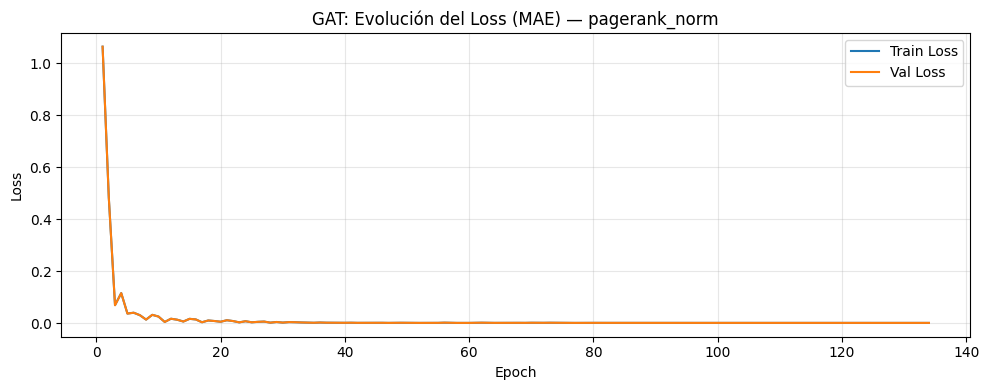

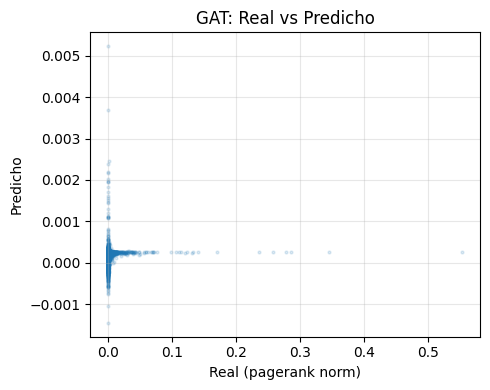


  [Métricas GAT]
  Best Val MAE : 0.000903
  Test MAE     : 0.000817
  Test R²      : -0.007234
  Guardado: embeddings_ribs_GAT_pagerank_norm.pt



In [ ]:
attr     = 'pagerank_norm'
features = gnn.dgl_graph.ndata['feat']
labels   = gnn.dgl_graph.ndata['pagerank_norm']

# Split: 64% train / 16% val / 20% test
train_mask_orig     = gnn.dgl_graph.ndata['train_mask']
test_mask           = gnn.dgl_graph.ndata['test_mask']
train_indices       = torch.where(train_mask_orig)[0]
g_seed              = torch.Generator().manual_seed(42)
perm                = torch.randperm(len(train_indices), generator=g_seed)
n_val               = int(0.2 * len(train_indices))
val_indices         = train_indices[perm[:n_val]]
train_indices_final = train_indices[perm[n_val:]]
val_mask  = torch.zeros(gnn.dgl_graph.num_nodes(), dtype=torch.bool)
val_mask[val_indices] = True
train_mask = torch.zeros(gnn.dgl_graph.num_nodes(), dtype=torch.bool)
train_mask[train_indices_final] = True
print(f'Split => Train: {train_mask.sum()} | Val: {val_mask.sum()} | Test: {test_mask.sum()}')

in_feats      = features.shape[1]
hidden_feats  = GLOBAL_CONFIG['hidden_dim']
out_feats     = GLOBAL_CONFIG['out_dim']
out_feats_mlp = 1
save_dir      = data_path + 'results/EnfoquePorPartes/Caso4'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=out_feats,
        out_feats_mlp=out_feats_mlp,
    )
    loss_fn   = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=GLOBAL_CONFIG['lr'],
                                 weight_decay=GLOBAL_CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss    = float('inf')
    best_state       = None
    patience_counter = 0

    t0 = time.perf_counter()
    for epoch in range(GLOBAL_CONFIG['epochs']):
        model.train()
        pred = model(gnn.dgl_graph, features)
        loss = loss_fn(pred[train_mask], labels[train_mask])
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_eval = model(gnn.dgl_graph, features)
            train_mae = loss_fn(pred_eval[train_mask], labels[train_mask]).item()
            val_mae   = loss_fn(pred_eval[val_mask],   labels[val_mask]).item()
        train_losses.append(train_mae)
        val_losses.append(val_mae)
        scheduler.step(val_mae)

        if epoch % 10 == 0 or epoch == GLOBAL_CONFIG['epochs'] - 1:
            print(f'  Epoch {epoch:3d}: train={train_mae:.6f}  val={val_mae:.6f}')

        if val_mae < best_val_loss:
            best_val_loss    = val_mae
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= GLOBAL_CONFIG['patience']:
            print(f'  Early stopping epoch {epoch}. Best val MAE: {best_val_loss:.6f}')
            break
    tiempo_total = time.perf_counter() - t0
    print(f'Modelo {model_name} finalizado en {tiempo_total:.2f} segundos')

    model.load_state_dict(best_state)
    model.eval()

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name}: Evolución del Loss (MAE) — pagerank_norm',
                        val_losses=val_losses)

    with torch.no_grad():
        pred_final = model(gnn.dgl_graph, features)
        embeddings = model.encode(gnn.dgl_graph, features)

    pred_test   = pred_final[test_mask].cpu().numpy().flatten()
    labels_test = labels[test_mask].cpu().numpy().flatten()
    test_mae    = loss_fn(pred_final[test_mask], labels[test_mask]).item()
    r2          = r2_score(labels_test, pred_test)

    plt.figure(figsize=(5, 4))
    plt.scatter(labels_test, pred_test, alpha=0.15, s=4)
    plt.xlabel('Real (pagerank norm)')
    plt.ylabel('Predicho')
    plt.title(f'{model_name}: Real vs Predicho')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n  [Métricas {model_name}]')
    print(f'  Best Val MAE : {best_val_loss:.6f}')
    print(f'  Test MAE     : {test_mae:.6f}')
    print(f'  Test R²      : {r2:.6f}')

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{model_name}_{attr}.pth')
    torch.save(embeddings,
               f'{save_dir}/embeddings_ribs_{model_name}_{attr}.pt')
    print(f'  Guardado: embeddings_ribs_{model_name}_{attr}.pt')
    print()

In [ ]:
# # Guardar los mismos embeddings con el prefijo 'mlp' para mantener
# # la convención de nombres usada en Caso 0 / Caso 1.
# # El entrenamiento es node-regression en ambas variantes; el sufijo
# # indica la nomenclatura del decoder simbólico del enfoque staged.

# save_dir = data_path + 'results/EnfoquePorPartes/Caso4'
# attr     = 'pagerank_norm'

# for model_name in ['GCN', 'GraphSAGE', 'GAT']:
#     src_path = f'{save_dir}/embeddings_ribs_{model_name}_{attr}.pt'
#     dst_path = f'{save_dir}/embeddings_mlp_{model_name}_{attr}.pt'
#     if os.path.exists(src_path):
#         import shutil
#         shutil.copy2(src_path, dst_path)
#         print(f'  Copiado: embeddings_mlp_{model_name}_{attr}.pt')
#     else:
#         print(f'  [AVISO] No encontrado: {src_path}  — ejecuta la celda anterior primero.')


  Copiado: embeddings_mlp_GCN_pagerank_norm.pt
  Copiado: embeddings_mlp_GraphSAGE_pagerank_norm.pt
  Copiado: embeddings_mlp_GAT_pagerank_norm.pt


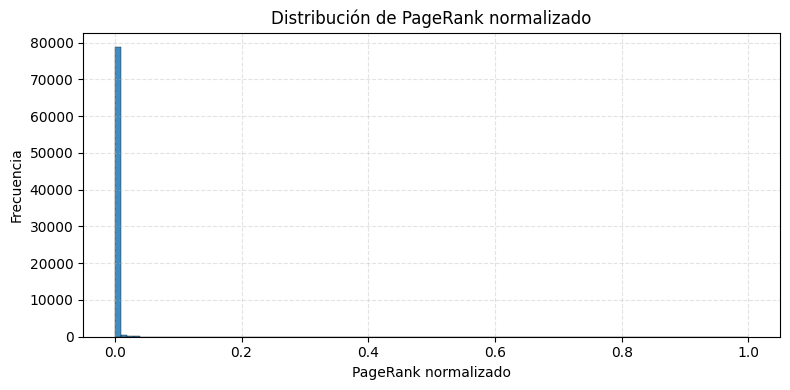

In [ ]:


# Distribución de PageRank normalizado (min-max)
pr_norm = gnn.dgl_graph.ndata['pagerank_norm'].squeeze().detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.hist(pr_norm, bins=100, alpha=0.85, edgecolor='black', linewidth=0.3)
plt.title('Distribución de PageRank normalizado')
plt.xlabel('PageRank normalizado')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()



### Caso 5: Creación de embeddings a partir de DeepWalk y BGP2Vec 

### Caso 5.1: DeepWalk

In [37]:
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))
NUM_EPOCHS = 50


Grafo cargado: 79504 nodos, 807496 aristas
Aristas en ambos sentidos: True
Dimensión de entrada (in_feats): 72
Edge features: 1 dim


In [39]:
from dgl.nn import DeepWalk
from torch.optim import SparseAdam

# Configuración del modelo DeepWalk
# -------------------------------------
model = DeepWalk(
    gnn.dgl_graph,
    emb_dim=32,
    walk_length=40,
    window_size=1
)

# DataLoader para muestreo de caminatas aleatorias
# -------------------------------------------------
# Usar explícitamente el DataLoader de PyTorch (no el de DGL)
import torch.utils.data
dataloader = torch.utils.data.DataLoader(
    torch.arange(gnn.dgl_graph.num_nodes()),
    batch_size=128,
    shuffle=True,
    collate_fn=model.sample
)

optimizer = SparseAdam(model.parameters(), lr=0.01)

# Entrenamiento
# -------------------------------------
losses = []

print("=" * 60)
print("Iniciando entrenamiento de DeepWalk...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    num_batches = 0
    
    for batch_walk in dataloader:
        # Identificar cuáles filas NO tienen -1 (caminatas válidas)
        valid_mask = ~(batch_walk == -1).any(dim=1)
        
        # Filtrar filas válidas
        batch_walk_clean = batch_walk[valid_mask]
        
        # Si no hay caminatas válidas en el batch, continuar
        if batch_walk_clean.size(0) == 0:
            continue

        # Forward + backward
        loss = model(batch_walk_clean)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    # Calcular pérdida promedio de la época
    avg_loss = epoch_loss / num_batches if num_batches > 0 else 0
    losses.append(avg_loss)
    
    # Mostrar progreso
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS}: Loss = {avg_loss:.6f}")

print("\n" + "=" * 60)
print("Entrenamiento completado!")
print("=" * 60)

# Obtener embeddings finales
# -------------------------------------
embeddings = model.node_embed.weight.detach().cpu()

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Número de nodos: {gnn.dgl_graph.num_nodes()}")
print(f"Dimensión de embeddings: {embeddings.shape[1]}")
print(f"\nLoss inicial: {losses[0]:.6f}")
print(f"Loss final: {losses[-1]:.6f}")
print(f"Reducción: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")

# 38 min
# 35 min

Iniciando entrenamiento de DeepWalk...
Epoch   1/50: Loss = 2.596896
Epoch  10/50: Loss = 0.872682
Epoch  20/50: Loss = 0.844898
Epoch  30/50: Loss = 0.834071
Epoch  40/50: Loss = 0.828198
Epoch  50/50: Loss = 0.824646

Entrenamiento completado!

Embeddings shape: torch.Size([79504, 32])
Número de nodos: 79504
Dimensión de embeddings: 32

Loss inicial: 2.596896
Loss final: 0.824646
Reducción: 68.24%


Evolución del Loss durante el entrenamiento

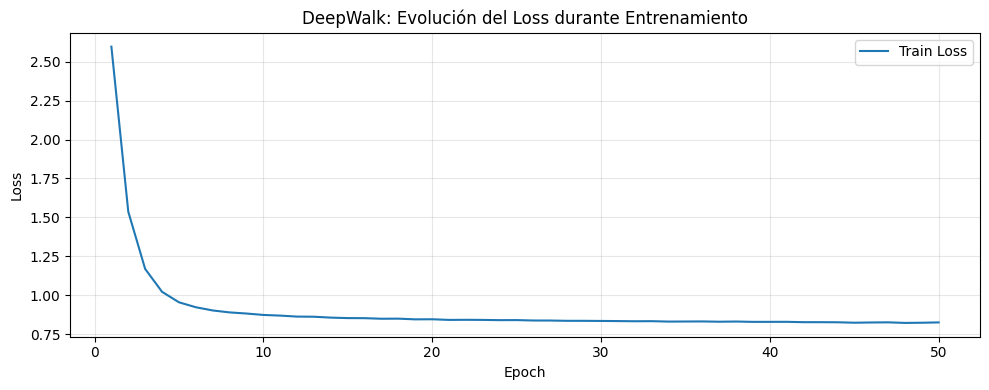

In [42]:
plot_loss_evolution(losses, NUM_EPOCHS, title='DeepWalk: Evolución del Loss durante Entrenamiento')

In [43]:
MES = "marzo"
ANO = "2026"

In [44]:
# Crear directorio si no existe
import os
save_dir = data_path + 'results/EnfoquePorPartes/Caso5/'
os.makedirs(save_dir, exist_ok=True)

# Guardar los embeddings
embeddings_path = save_dir + f'embeddings_deepWalk_{MES}_{ANO}.pt'
torch.save(embeddings, embeddings_path)

# Guardar el modelo completo
model_path = save_dir + f'model_deepWalk_{MES}_{ANO}.pth'
torch.save(model.state_dict(), model_path)

print('=' * 60)
print('ARCHIVOS GUARDADOS')
print('=' * 60)
print(f'Embeddings guardados en: {embeddings_path}')
print(f'Modelo guardado en: {model_path}')
print(f'\nShape embeddings: {embeddings.shape}')


ARCHIVOS GUARDADOS
Embeddings guardados en: /media/vale/KINGSTON/TESIS/data_2026/results/EnfoquePorPartes/Caso5/embeddings_deepWalk_marzo_2026.pt
Modelo guardado en: /media/vale/KINGSTON/TESIS/data_2026/results/EnfoquePorPartes/Caso5/model_deepWalk_marzo_2026.pth

Shape embeddings: torch.Size([79504, 32])


### Caso 5.2 BGP2Vec

In [45]:
from gensim.models import Word2Vec


In [46]:
MODELS_PATH = data_path + 'results/EnfoquePorPartes/Caso5/'
print(f"[Modelos guardados en]: {MODELS_PATH}]")
print(f"[Archivo con RIBs]: {ribs_file}")



[Modelos guardados en]: /media/vale/KINGSTON/TESIS/data_2026/results/EnfoquePorPartes/Caso5/]
[Archivo con RIBs]: /media/vale/KINGSTON/TESIS/data_2026/rib_20260301_0000_to_20260301_1200.txt


#### Importar rutas BGP 

In [47]:
from modules.bgp2vec import RIBCorpus
import itertools

# Configuración
MAX_ROUTES_TRAIN = 5_000_000   # None => usar todas las rutas
COUNT_ALL_ROUTES = True       # True => recorre todo el archivo para contar

# Muestra pequeña para verificar formato
ribs_file =  data_path + "rib_20260301_0000_to_20260301_1200.txt" 
sample = list(itertools.islice(RIBCorpus(ribs_file, skip_header=True), 10))
print("[RUTAS BGP - MUESTRA]:", sample)

# Conteo total opcional (puede tardar porque recorre todo)
if COUNT_ALL_ROUTES:
    count_routes = sum(1 for _ in RIBCorpus(ribs_file, skip_header=True))
    print("[CANTIDAD TOTAL DE RUTAS BGP]:", count_routes)
else:
    print("[CANTIDAD TOTAL DE RUTAS BGP]: omitido (COUNT_ALL_ROUTES=False)")

# Corpus para entrenamiento: limitado o completo
if MAX_ROUTES_TRAIN is None:
    bgp_routes = RIBCorpus(ribs_file, skip_header=True)
    print("[RUTAS PARA ENTRENAR]: todas")
else:
    bgp_routes = itertools.islice(RIBCorpus(ribs_file, skip_header=True), MAX_ROUTES_TRAIN)
    print(f"[RUTAS PARA ENTRENAR]: primeras {MAX_ROUTES_TRAIN}")

print("[TIPO]:", type(bgp_routes))

[RUTAS BGP - MUESTRA]: [['6939', '38040', '38040', '38040', '38040', '23969'], ['6939', '4651', '4651', '23969'], ['6939', '4651', '4651', '23969', '23969'], ['6939', '4651', '4651', '23969', '23974'], ['6939', '38040', '23969'], ['6939', '38040', '38040', '38040', '38040', '23969', '23969'], ['6939', '38040', '23969', '23969'], ['6939', '4788', '4788'], ['6939', '38040', '23969', '23974'], ['6939', '4651', '4651', '23969', '56120']]
[CANTIDAD TOTAL DE RUTAS BGP]: 27112619
[RUTAS PARA ENTRENAR]: primeras 5000000
[TIPO]: <class 'itertools.islice'>


#### Crear Embeddings

In [48]:
MODELS_PATH = data_path + 'results/EnfoquePorPartes/Caso5/'

In [49]:
data_path

'/media/vale/KINGSTON/TESIS/data_2026/'

In [50]:
from modules.bgp2vec import BGP2VEC

test_limit = 27000000 #cantidad paths/horaciones
mode = None# 'test' # par limitar cantidad de paths/oraciones
epochs = 1
debug = True

# Crea embeddings de ASN con  BGP2VEC y lo guarda en "bgp2vec/bgp2vec.word2vec"
bgp2vec = BGP2VEC(model_path = MODELS_PATH + 'bgp2vec.word2vec',
                  bgp_routes=bgp_routes,
                  rewrite=True, 
                  test_limit= test_limit, 
                  mode = mode, 
                  epochs = epochs)

print("[MODELO]",bgp2vec.model)
print("[NUMERO ASN REPETIDOS Y TODO]",bgp2vec.model.corpus_total_words)

# 1.000.000 -> 7 seg
# 2.000.000 -> 14 seeg
# todo el dataset (27.000.000) -> 5 min

[MODELO] Word2Vec<vocab=78702, vector_size=32, alpha=0.025>
[NUMERO ASN REPETIDOS Y TODO] 25372617


In [51]:
# Importar embeddings preentrenado de los ASN  con BGP2VEC
BGP2Vec_model = Word2Vec.load(MODELS_PATH + "bgp2vec.word2vec")

# Obtener la matriz de embeddings
embeddings = BGP2Vec_model.wv.vectors
total_ASNs, embedding_vecor_length = embeddings.shape


print(f"[TOTAL ASN]: {total_ASNs}" )
print(f"[EMBEDDINGS LEN]: {embedding_vecor_length}")
print(f"[EMBEDDINGS] {embeddings}")

[TOTAL ASN]: 78702
[EMBEDDINGS LEN]: 32
[EMBEDDINGS] [[ 0.02780656  0.00781846  0.01151124 ...  0.00028427  0.00515893
   0.00334358]
 [ 0.00059045  0.03096877  0.01922898 ... -0.00019541 -0.00753899
  -0.01578032]
 [ 0.03082822 -0.03051288 -0.02517547 ... -0.02553153 -0.01596969
   0.00257149]
 ...
 [-0.0050431  -0.00406004 -0.0170689  ... -0.00778058 -0.02599987
   0.00332969]
 [-0.01676342  0.00960786  0.02929788 ... -0.01886135  0.02650013
   0.02762555]
 [-0.02360468  0.02042373  0.01505933 ... -0.00348844  0.01427419
   0.00505327]]


In [52]:
# Mapeo ASN -> ID usado en los embeddings
asn_to_index = BGP2Vec_model.wv.key_to_index
print(f"[ASN TO INDEX]: {asn_to_index}")
print(f"[TAMANO]: {len(asn_to_index)}")

[ASN TO INDEX]: {'1299': 0, '3356': 1, '174': 2, '6939': 3, '2914': 4, '6453': 5, '6762': 6, '3257': 7, '32590': 8, '12956': 9, '199524': 10, '3491': 11, '6461': 12, '52468': 13, '49544': 14, '9002': 15, '3320': 16, '27678': 17, '150000': 18, '27986': 19, '7195': 20, '19151': 21, '8529': 22, '14259': 23, '30844': 24, '18187': 25, '7018': 26, '2497': 27, '138685': 28, '9498': 29, '38082': 30, '4637': 31, '37468': 32, '398465': 33, '9304': 34, '12389': 35, '137409': 36, '7470': 37, '5511': 38, '16552': 39, '52320': 40, '37271': 41, '142271': 42, '49666': 43, '60539': 44, '37100': 45, '8220': 46, '264409': 47, '1031': 48, '4755': 49, '53062': 50, '20940': 51, '17350': 52, '267613': 53, '7500': 54, '14537': 55, '2500': 56, '60068': 57, '25091': 58, '53828': 59, '6423': 60, '4181': 61, '6830': 62, '3701': 63, '20253': 64, '6082': 65, '6057': 66, '3216': 67, '20055': 68, '209823': 69, '38016': 70, '11399': 71, '4826': 72, '13335': 73, '42473': 74, '7922': 75, '13786': 76, '8888': 77, '262427

## Clasificación Aristas 

In [ ]:
# !pip uninstall gensim -y 
# %pip install gensim==4.3.3

In [ ]:
# !pip install scikit-learn
# !pip install numpy
# !pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
# # !pip uninstall tensorflow -y
# !pip install tensorflow==2.17.0
# !pip install matplotlib
# !pip install  dgl -f https://data.dgl.ai/wheels/torch-2.3/cu121/repo.html



In [4]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.insert(0, os.path.abspath("../.."))
import numpy as np
from collections import Counter
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
import torch



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
TOR_LABELS_DICT = {'P2P':0, 'C2P': 1,'P2C': 2}
TOR_CSV_LABELS_DICT = {'P2P':0,'P2C': -1}

TESIS_PATH  = '/media/vale/KINGSTON/TESIS/'
class_names = ['P2P', 'C2P', 'P2C']

# Dataset entrenamiento RNA para relaciones entre AS
MODEL_NAME = 'NN_Inference'
MES = 'marzo'



## Importar Emberddings

In [20]:
# Seleccionar embeddings a cargar
# Descomenta el bloque del caso que quieras usar

# # # ─── Caso 0: link prediction, atributos PeeringDB (mis_attr_marzo) ───────────
attr = 'mis_attr_marzo'
CASO = "Caso0"
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GCN_mis_attr_marzo.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GraphSAGE_mis_attr_marzo.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GAT_mis_attr_marzo.pt'
embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_MLP_GCN_mis_attr_marzo.pt'
embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_MLP_GraphSAGE_mis_attr_marzo.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_MLP_GAT_mis_attr_marzo.pt'

# ─── Caso 1: link prediction, atributos grado entrada/salida ──────────────────
# attr = 'grado_attr_febrero'
# CASO = 'Caso1'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GCN_grado_attr_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GraphSAGE_grado_attr_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GAT_grado_attr_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_MLP_GCN_grado_attr_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_MLP_GraphSAGE_grado_attr_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_MLP_GAT_grado_attr_febrero.pt'

# ─── Caso 3: regresión grado de salida ───────────────────────────────────────
# attr = 'out_degree'
# CASO = 'Caso3'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GCN_out_degree.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GraphSAGE_out_degree.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GAT_out_degree.pt'

# ─── Caso 4: regresión PageRank ───────────────────────────────────────────────
# attr = 'pagerank_norm'
# CASO = 'Caso4'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GCN_pagerank_norm.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GraphSAGE_pagerank_norm.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GAT_pagerank_norm.pt'

# ─── Caso 5.1: DeepWalk ─────────────────────────────────────────────────────────
# attr = 'deepWalk'
# CASO = 'Caso5'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_deepWalk_marzo_2026.pt'
# embeddings_path =  "/home/vale/Escritorio/GIT/TrabajoTesis/results/EnfoquePorPartes/Caso5/embeddings_deepWalk_marzo_2026.pt"
# # Modelo guardado en: /home/vale/Escritorio/GIT/TrabajoTesis/results/EnfoquePorPartes/Caso5/model_deepWalk_marzo_2026.pth
# print('Cargando:', embeddings_path)

# ─── Caso 5.2: BGP2Vec ───────────────────────────────────────────────

# Caso 5: BGP2Vvec
attr = 'bgp2vec'
CASO = "Caso5"

save_dir = data_path + 'results/EnfoquePorPartes/Caso5/'
embeddings_path = data_path + 'results/EnfoquePorPartes/Caso5/bgp2vec.word2vec'



In [21]:
save_dir = data_path + f'results/EnfoquePorPartes/{CASO}/'

if attr != 'bgp2vec':
    print ("=" * 60)
    print(f"Cargando embeddings de: {embeddings_path}")
    print ("=" * 60)
    embeddings_name = embeddings_path.split('/')[-1].split('.')[0]  # Nombre del archivo sin extensión
    embeddings_pt = torch.load(embeddings_path)  # asegúrate que sea un tensor
    embeddings = embeddings_pt.detach().numpy()

if attr == 'bgp2vec':
    from gensim.models import Word2Vec
    # Si son los mbddings de BGP2Vec, cargamos con gensim
    print ("=" * 60)
    print(f"Cargando embeddings BGP2Vec: {embeddings_path}")
    print ("=" * 60)
    embeddings_name = "bgp2vec"  # Nombre del archivo sin extensión

    BGP2Vec_model = Word2Vec.load(embeddings_path)

    # Obtener la matriz de embeddings
    embeddings = BGP2Vec_model.wv.vectors

    asn_to_index = BGP2Vec_model.wv.key_to_index
    print(f"[ASN TO INDEX]: {asn_to_index}")
    print(f"[TAMANO]: {len(asn_to_index)}")

total_ASNs, embedding_vecor_length = embeddings.shape


print(f"[TOTAL ASN]: {total_ASNs}" )
print(f"[EMBEDDINGS LEN]: {embedding_vecor_length}")
print(f"[EMBEDDINGS] {embeddings}")





Cargando embeddings BGP2Vec: /media/vale/KINGSTON/TESIS/data_2026/results/EnfoquePorPartes/Caso5/bgp2vec.word2vec
[ASN TO INDEX]: {'1299': 0, '3356': 1, '174': 2, '6939': 3, '2914': 4, '6453': 5, '6762': 6, '3257': 7, '32590': 8, '12956': 9, '199524': 10, '3491': 11, '6461': 12, '52468': 13, '49544': 14, '9002': 15, '3320': 16, '27678': 17, '150000': 18, '27986': 19, '7195': 20, '19151': 21, '8529': 22, '14259': 23, '30844': 24, '18187': 25, '7018': 26, '2497': 27, '138685': 28, '9498': 29, '38082': 30, '4637': 31, '37468': 32, '398465': 33, '9304': 34, '12389': 35, '137409': 36, '7470': 37, '5511': 38, '16552': 39, '52320': 40, '37271': 41, '142271': 42, '49666': 43, '60539': 44, '37100': 45, '8220': 46, '264409': 47, '1031': 48, '4755': 49, '53062': 50, '20940': 51, '17350': 52, '267613': 53, '7500': 54, '14537': 55, '2500': 56, '60068': 57, '25091': 58, '53828': 59, '6423': 60, '4181': 61, '6830': 62, '3701': 63, '20253': 64, '6082': 65, '6057': 66, '3216': 67, '20055': 68, '209823'

## Clasificación de Tipos de Enlace con ANN

Se cargan los embeddings GNN ya entrenados y el dataset ToR (pares de ASNs con etiqueta P2P/C2P/P2C).
Para cada par (ASN_u, ASN_v) se construye un vector de arista **[e_u | e_v | e_u−e_v | e_u·e_v]** que se pasa a un clasificador MLP.

El notebook está organizado en:
1. Carga y exploración del dataset ToR
2. Mapeo ASN → node_id y construcción vectorizada de features de arista
3. Definición del modelo ANN
4. Entrenamiento **sin batches** (dataset completo en memoria)
5. Entrenamiento **con batches** (DataLoader)
6. Evaluación final: accuracy, reporte por clase, matrices de confusión

### 1. Configuración

In [22]:
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
MES  = 'marzo'
ANO  = '2026'
TESIS_PATH = '/media/vale/KINGSTON/TESIS/'
TOR_PATH   = TESIS_PATH + f'data_2026/ToR_data/tor_data_{MES}/'

CLASS_NAMES = ['P2P', 'C2P', 'P2C']
N_CLASSES   = 3

# Hiperparámetros ANN
ANN_HIDDEN   = 256
ANN_DROPOUT  = 0.3
ANN_LR       = 1e-3 # 0,001
ANN_EPOCHS   = 200
ANN_PATIENCE = 50
ANN_BATCH    = 512 #4096
VAL_SIZE     = 0.2



### 2. Cargar Dataset ToR

In [23]:
# x contiene pares de ASNs (strings), y contiene etiquetas 0/1/2
x_train_raw = np.load(TOR_PATH + 'x_training.npy')          # (N, 2) dtype=str
x_test_raw  = np.load(TOR_PATH + 'x_test.npy')
y_train_raw = np.load(TOR_PATH + 'y_training.npy').astype(int)
y_test_raw  = np.load(TOR_PATH + 'y_test.npy').astype(int)

print(f'Train: {x_train_raw.shape}  dtype={x_train_raw.dtype}')
print(f'Test:  {x_test_raw.shape}')
print(f'Distribución y_train: {dict(sorted(Counter(y_train_raw.tolist()).items()))}')
print(f'Distribución y_test:  {dict(sorted(Counter(y_test_raw.tolist()).items()))}')
print(f'Ejemplo x_train[0]: ASN_u={x_train_raw[0,0]}  ASN_v={x_train_raw[0,1]}')


Train: (805489, 2)  dtype=<U6
Test:  (201373, 2)
Distribución y_train: {0: 543374, 1: 130893, 2: 131222}
Distribución y_test:  {0: 135788, 1: 32957, 2: 32628}
Ejemplo x_train[0]: ASN_u=6853  ASN_v=39120


### 3. Mapeo ASN → node_id y Features de Arista

Los embeddings están indexados por `node_id` (fila en el grafo DGL), pero el dataset ToR usa ASNs.
Se carga el CSV de nodos para construir el diccionario `asn → node_id`.

In [24]:
if attr != 'bgp2vec':
    print ("=" * 60)
    print(f"Mapeo de nodos en el grafo a partir del CSV de nodos: {nodes_file}")
    print ("=" * 60)

    # Construir mapeo {asn(int) -> node_id(int)} desde el CSV de nodos
    nodes_df = pd.read_csv(str(nodes_file))
    asn_to_nodeid = dict(zip(nodes_df['asn'].astype(int), nodes_df['node_id'].astype(int)))

if attr == 'bgp2vec':
    print ("=" * 60)
    print(f"Mapeo de nodos en el grafo a partir de bgp2vec: {nodes_file}")
    print ("=" * 60)

    raw_index = BGP2Vec_model.wv.key_to_index
    asn_to_nodeid = {}
    invalid_tokens = []

    for k, v in raw_index.items():
        k_str = str(k).strip()
        if not k_str:
            invalid_tokens.append(k)
            continue
        try:
            asn_to_nodeid[int(k_str)] = v
        except ValueError:
            invalid_tokens.append(k)

    print(f"[ASN válidos]: {len(asn_to_nodeid):,}")
    print(f"[ASN inválidos descartados]: {len(invalid_tokens):,}")
    if invalid_tokens:
        print(f"[Muestra inválidos]: {invalid_tokens[:10]}")

print(f'[Nodos en el grafo]:    {len(asn_to_nodeid):,}')
print(f'[ASNs en x_train]:      {len(set(x_train_raw.flatten())):,} únicos')

# Cobertura: ¿cuántos ASNs del ToR están en el grafo?
asns_tor = set(int(a) for a in x_train_raw.flatten())
covered = asns_tor & set(asn_to_nodeid.keys())
print(f'[Cobertura]:            {len(covered):,} / {len(asns_tor):,} ({len(covered)/len(asns_tor)*100:.1f}%)')

Mapeo de nodos en el grafo a partir de bgp2vec: /media/vale/KINGSTON/TESIS/data_2026//nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv
[ASN válidos]: 78,702
[ASN inválidos descartados]: 0
[Nodos en el grafo]:    78,702
[ASNs en x_train]:      77,905 únicos
[Cobertura]:            77,244 / 77,905 (99.2%)


In [25]:
def build_edge_features(x_pairs, emb_tensor, asn_to_nodeid):
    """
    Construye features de arista [e_u | e_v | e_u-e_v | e_u*e_v] de forma vectorizada.

    Args:
        x_pairs       : (N, 2) array de ASNs (strings o ints)
        emb_tensor    : (num_nodes, emb_dim) float tensor o numpy array
        asn_to_nodeid : dict {asn(int|str) -> node_id(int)}

    Returns:
        feats  : (M, 4*emb_dim) float tensor  (M <= N, solo pares válidos)
        valid  : (N,) bool array  (True si ambos ASNs están en el grafo)
    """
    # Asegurar tensor PyTorch para operaciones posteriores (torch.cat)
    emb_tensor = torch.as_tensor(emb_tensor, dtype=torch.float32)

    def _lookup_nid(asn_val):
        asn_int = int(asn_val)
        # Compatibilidad: diccionarios con claves int (GNN) o str (BGP2Vec)
        return asn_to_nodeid.get(asn_int, asn_to_nodeid.get(str(asn_int), -1))

    nid_u = np.array([_lookup_nid(a) for a in x_pairs[:, 0]], dtype=np.int64)
    nid_v = np.array([_lookup_nid(a) for a in x_pairs[:, 1]], dtype=np.int64)
    valid = (nid_u >= 0) & (nid_v >= 0)

    # Si no hay pares válidos, devolver tensor vacío con dimensión correcta
    if valid.sum() == 0:
        empty_feats = torch.empty((0, emb_tensor.shape[1] * 4), dtype=emb_tensor.dtype)
        return empty_feats, valid

    idx_u = torch.as_tensor(nid_u[valid], dtype=torch.long)
    idx_v = torch.as_tensor(nid_v[valid], dtype=torch.long)

    e_u = emb_tensor[idx_u]          # (M, D)
    e_v = emb_tensor[idx_v]          # (M, D)
    feats = torch.cat([e_u, e_v, e_u - e_v, e_u * e_v], dim=1)  # (M, 4D)
    return feats, valid


# embeddings cargado en la sección 'Importar Embeddings' (celdas anteriores)
emb_tensor = torch.as_tensor(embeddings, dtype=torch.float32)
emb_dim    = emb_tensor.shape[1]
print(f'Embeddings: {tuple(emb_tensor.shape)}  →  features por arista: {4 * emb_dim}')

print('Construyendo features de entrenamiento...')
X_train_feat, train_valid = build_edge_features(x_train_raw, emb_tensor, asn_to_nodeid)
y_train_feat = y_train_raw[train_valid]
print(f'  {x_train_raw.shape[0]:,} pares → {train_valid.sum():,} válidos '
      f'({train_valid.mean()*100:.1f}%)')

print('Construyendo features de test...')
X_test_feat, test_valid = build_edge_features(x_test_raw, emb_tensor, asn_to_nodeid)
y_test_feat = y_test_raw[test_valid]
print(f'  {x_test_raw.shape[0]:,} pares → {test_valid.sum():,} válidos '
      f'({test_valid.mean()*100:.1f}%)')

Embeddings: (78702, 32)  →  features por arista: 128
Construyendo features de entrenamiento...
  805,489 pares → 795,312 válidos (98.7%)
Construyendo features de test...
  201,373 pares → 198,920 válidos (98.8%)


### 4. Preparar Tensores y Pesos de Clase

In [26]:
# Train / Val split estratificado (80/20 del training)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_feat, y_train_feat,
    test_size=VAL_SIZE, random_state=42, stratify=y_train_feat)

y_tr_t  = torch.tensor(y_tr,  dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_te_t  = torch.tensor(y_test_feat, dtype=torch.long)

print(f'Train: {len(X_tr):,}  Val: {len(X_val):,}  Test: {len(X_test_feat):,}')
print(f'y_tr  dist: {dict(sorted(Counter(y_tr.tolist()).items()))}')

# Pesos de clase para compensar desbalance P2P >> C2P, P2C
cw = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr)
class_weights = torch.tensor(cw, dtype=torch.float)
print(f'Class weights: P2P={cw[0]:.3f}  C2P={cw[1]:.3f}  P2C={cw[2]:.3f}')


Train: 636,249  Val: 159,063  Test: 198,920
y_tr  dist: {0: 428496, 1: 103737, 2: 104016}
Class weights: P2P=0.495  C2P=2.044  P2C=2.039


### 5.1 Definición del Modelo ANN

El vector de entrada es **[e_u | e_v | e_u−e_v | e_u·e_v]** (4×emb_dim).
La diferencia y el producto capturan la **asimetría direccional** necesaria para separar C2P de P2C.

In [27]:
import torch.nn as nn
import torch.nn.functional as F

class EdgeClassifierANN(nn.Module):
    """
    MLP que clasifica el tipo de enlace AS (P2P / C2P / P2C)
    a partir del vector de arista [e_u | e_v | e_u-e_v | e_u*e_v].
    """
    def __init__(self, emb_dim, n_classes=3, hidden=256, dropout=0.3):
        super().__init__()
        in_dim = 4 * emb_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, x):    # x: (batch, 4*emb_dim)
        return self.net(x)


# Verificar dimensiones
_m = EdgeClassifierANN(emb_dim, N_CLASSES, ANN_HIDDEN, ANN_DROPOUT)
_x = torch.randn(4, 4 * emb_dim)
print(f'Test forward: input={_x.shape}  output={_m(_x).shape}')
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {n_params:,}')
del _m, _x


Test forward: input=torch.Size([4, 128])  output=torch.Size([4, 3])
Parámetros entrenables: 67,075


### 5.2 Definición y entrenamieneto del Modelo CNN 

In [28]:
# import torch
# import torch.nn as nn
# from torch.utils.data import TensorDataset, DataLoader


# class EdgeClassifierCNN(nn.Module):
#     """
#     CNN 1D que clasifica el tipo de enlace AS (P2P / C2P / P2C) a partir del
#     vector de arista pre-calculado [e_u | e_v | e_u-e_v | e_u*e_v].

#     Trata los 4 componentes como una secuencia de 4 'tokens' de dimensión emb_dim
#     y aplica Conv1D para capturar patrones locales entre ellos.

#     Input:  (batch, 4 * emb_dim)  — mismo formato que EdgeClassifierANN
#     """

#     def __init__(self, emb_dim, n_classes=3, dropout=0.3):
#         super().__init__()
#         self.emb_dim = emb_dim

#         # Reshape interno: (batch, 4*emb_dim) → (batch, emb_dim, 4)
#         self.conv1 = nn.Conv1d(emb_dim, 64, kernel_size=2, padding=1)
#         self.pool1 = nn.MaxPool1d(kernel_size=2)

#         self.conv2 = nn.Conv1d(64, 32, kernel_size=2, padding=0)
#         self.pool2 = nn.AdaptiveMaxPool1d(1)   # → (batch, 32, 1)

#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(32, 100),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(100, n_classes),
#         )

#     def forward(self, x):                       # x: (batch, 4*emb_dim)
#         b = x.size(0)
#         x = x.view(b, 4, self.emb_dim)         # (batch, 4, emb_dim)
#         x = x.permute(0, 2, 1)                 # (batch, emb_dim, 4)
#         x = torch.relu(self.conv1(x))           # (batch, 64, ≤5)
#         x = self.pool1(x)                       # (batch, 64, ≤2)
#         x = torch.relu(self.conv2(x))           # (batch, 32, ≤1)
#         x = self.pool2(x)                       # (batch, 32, 1)
#         return self.classifier(x)


In [29]:
# def train_cnn(model, X_tr, y_tr_t, X_val, y_val_t, X_test, y_te_t,
#               class_weights=None,
#               CNN_BATCH=64, CNN_EPOCHS=100, CNN_LR=1e-3,
#               CNN_PATIENCE=10, N_CLASSES=3, CLASS_NAMES=None):
#     """
#     Entrenamiento CNN con early stopping y evaluación final en test.
#     Acepta features de arista pre-calculadas (batch, 4*emb_dim).
#     """
#     from sklearn.metrics import accuracy_score, classification_report

#     loss_fn = nn.CrossEntropyLoss(weight=class_weights)

#     ds_train   = TensorDataset(X_tr,  y_tr_t)
#     ds_val     = TensorDataset(X_val, y_val_t)
#     loader_tr  = DataLoader(ds_train, batch_size=CNN_BATCH,     shuffle=True,  drop_last=False)
#     loader_val = DataLoader(ds_val,   batch_size=CNN_BATCH * 4, shuffle=False)

#     opt   = torch.optim.Adam(model.parameters(), lr=CNN_LR)
#     sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
#         opt, mode='min', factor=0.5, patience=5, verbose=False)

#     train_losses, val_losses = [], []
#     best_val, best_state, patience_ctr = float('inf'), None, 0

#     print('=' * 60)
#     print(f'CNN  (batch={CNN_BATCH})')
#     print('=' * 60)

#     for epoch in range(CNN_EPOCHS):

#         # ── Train ──────────────────────────────────────────────────────
#         model.train()
#         epoch_loss = 0
#         for x_b, y_b in loader_tr:
#             logits = model(x_b)
#             loss   = loss_fn(logits, y_b)
#             opt.zero_grad(); loss.backward(); opt.step()
#             epoch_loss += loss.item()
#         avg_train = epoch_loss / len(loader_tr)

#         # ── Validation ─────────────────────────────────────────────────
#         model.eval()
#         val_loss, n_correct = 0, 0
#         with torch.no_grad():
#             for x_b, y_b in loader_val:
#                 logits    = model(x_b)
#                 val_loss += loss_fn(logits, y_b).item()
#                 n_correct += (logits.argmax(1) == y_b).sum().item()
#         avg_val = val_loss / len(loader_val)
#         val_acc = n_correct / len(X_val)

#         train_losses.append(avg_train)
#         val_losses.append(avg_val)
#         sched.step(avg_val)

#         if epoch % 10 == 0 or epoch == CNN_EPOCHS - 1:
#             print(f'  Epoch {epoch:3d}: train={avg_train:.4f}  '
#                   f'val={avg_val:.4f}  val_acc={val_acc*100:.2f}%')

#         # ── Early stopping ─────────────────────────────────────────────
#         if avg_val < best_val:
#             best_val    = avg_val
#             best_state  = {k: v.clone() for k, v in model.state_dict().items()}
#             patience_ctr = 0
#         else:
#             patience_ctr += 1
#         if patience_ctr >= CNN_PATIENCE:
#             print(f'  Early stopping en epoch {epoch}.')
#             break

#     model.load_state_dict(best_state)
#     print(f'Mejor val loss: {best_val:.4f}')

#     # ── Evaluación en test ─────────────────────────────────────────────
#     print('=' * 60)
#     print('EVALUACIÓN EN TEST SET')
#     print('=' * 60)

#     model.eval()
#     all_preds = []
#     loader_te = DataLoader(TensorDataset(X_test), batch_size=CNN_BATCH * 4)
#     with torch.no_grad():
#         for (x_b,) in loader_te:
#             all_preds.append(model(x_b).argmax(1))
#     preds_test = torch.cat(all_preds).numpy()
#     y_te_np    = y_te_t.numpy()

#     print(f'Accuracy: {accuracy_score(y_te_np, preds_test)*100:.2f}%\n')
#     if CLASS_NAMES:
#         print(classification_report(y_te_np, preds_test, target_names=CLASS_NAMES))

#     return model, train_losses, val_losses


In [30]:
# CNN_BATCH    = 4096
# CNN_EPOCHS   = 100
# CNN_LR       = 1e-3
# CNN_PATIENCE = 20
# CNN_DROPOUT  = 0.3

# model_cnn = EdgeClassifierCNN(emb_dim, n_classes=N_CLASSES, dropout=CNN_DROPOUT)

# model_cnn, tr_losses_cnn, val_losses_cnn = train_cnn(
#     model_cnn,
#     X_tr, y_tr_t,
#     X_val, y_val_t,
#     X_test_feat, y_te_t,
#     class_weights=class_weights,
#     CNN_BATCH=CNN_BATCH, CNN_EPOCHS=CNN_EPOCHS, CNN_LR=CNN_LR,
#     CNN_PATIENCE=CNN_PATIENCE, N_CLASSES=N_CLASSES, CLASS_NAMES=CLASS_NAMES,
# )


#### Curvas de Loss — CNN

In [31]:
# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(tr_losses_cnn,  label='Train', linewidth=1.5)
# ax.plot(val_losses_cnn, label='Val',   linewidth=1.5)
# ax.set_title(f'Evolución del Loss – CNN Clasificador AS ({embeddings_name})')
# ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
# ax.legend(); ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig(save_dir + f'loss_cnn_{embeddings_name}.png', dpi=150)
# plt.show()


### 6. Entrenamiento Sin Batches

Todo el conjunto de entrenamiento se pasa de una vez en cada época. Funciona bien si los datos caben en GPU/RAM.

In [32]:
# # Entrenamiento full-batch (sin DataLoader)
# loss_fn_nb = nn.CrossEntropyLoss(weight=class_weights)
# model_nb = EdgeClassifierANN(emb_dim, N_CLASSES, ANN_HIDDEN, ANN_DROPOUT)
# opt_nb = torch.optim.Adam(model_nb.parameters(), lr=ANN_LR)
# sched_nb = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     opt_nb, mode='min', factor=0.5, patience=5, verbose=False)

# train_losses_nb, val_losses_nb = [], []
# best_val_nb, best_state_nb, patience_ctr_nb = float('inf'), None, 0

# print('=' * 60)
# print('Sin Batches (full-batch)')
# print('=' * 60)
# for epoch in range(ANN_EPOCHS):
#     # ── Train ──
#     model_nb.train()
#     logits_tr = model_nb(X_tr)
#     loss_tr = loss_fn_nb(logits_tr, y_tr_t)
#     opt_nb.zero_grad()
#     loss_tr.backward()
#     opt_nb.step()
#     avg_train = loss_tr.item()

#     # ── Val ──
#     model_nb.eval()
#     with torch.no_grad():
#         logits_val = model_nb(X_val)
#         avg_val = loss_fn_nb(logits_val, y_val_t).item()
#         val_acc = (logits_val.argmax(1) == y_val_t).float().mean().item()

#     train_losses_nb.append(avg_train)
#     val_losses_nb.append(avg_val)
#     sched_nb.step(avg_val)

#     if epoch % 10 == 0 or epoch == ANN_EPOCHS - 1:
#         print(f'Epoch {epoch:3d}: train={avg_train:.4f}  val={avg_val:.4f}  val_acc={val_acc*100:.2f}%')

#     # ── Early stopping ──
#     if avg_val < best_val_nb:
#         best_val_nb = avg_val
#         best_state_nb = {k: v.clone() for k, v in model_nb.state_dict().items()}
#         patience_ctr_nb = 0
#     else:
#         patience_ctr_nb += 1

#     if patience_ctr_nb >= ANN_PATIENCE:
#         print(f'Early stopping epoch {epoch}.')
#         break

# if best_state_nb is not None:
#     model_nb.load_state_dict(best_state_nb)

# print(f'Mejor val loss (sin batches): {best_val_nb:.4f}')
# print(f"Mejor accuracy en val (sin batches): {(logits_val.argmax(1) == y_val_t).float().mean().item()*100:.2f}%")

# #################################################################################
# # Elegir modelo: sin batches 
# #################################################################################
# print("=" * 60)
# print('Evaluación en test set')
# print("=" * 60)

# best_model = model_nb  #model_nb

# best_model.eval()
# all_preds = []
# loader_te = DataLoader(TensorDataset(X_test_feat), batch_size=ANN_BATCH * 4)
# with torch.no_grad():
#     for (x_b,) in loader_te:
#         all_preds.append(best_model(x_b).argmax(1))
# preds_test = torch.cat(all_preds).numpy()
# y_te_np    = y_te_t.numpy()

# print('=' * 60)
# print('EVALUACIÓN EN TEST SET')
# print('=' * 60)
# print(f'Accuracy: {accuracy_score(y_te_np, preds_test)*100:.2f}%\n')
# print(classification_report(y_te_np, preds_test, target_names=CLASS_NAMES))

### 7. Entrenamiento Con Batches (DataLoader)

Más eficiente en memoria y con mejor generalización gracias al ruido de mini-batch.

Con Batches (batch=512) 


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.9285  val=0.7921  val_acc=67.03%
  Epoch  10: train=0.5421  val=0.4441  val_acc=85.18%
  Epoch  20: train=0.5036  val=0.4112  val_acc=85.66%
  Epoch  30: train=0.4892  val=0.3996  val_acc=85.56%
  Epoch  40: train=0.4800  val=0.3910  val_acc=86.10%
  Epoch  50: train=0.4735  val=0.3828  val_acc=86.26%
  Epoch  60: train=0.4686  val=0.3821  val_acc=86.13%
  Epoch  70: train=0.4544  val=0.3717  val_acc=87.02%
  Epoch  80: train=0.4517  val=0.3690  val_acc=86.68%
  Epoch  90: train=0.4518  val=0.3665  val_acc=86.76%
  Epoch 100: train=0.4460  val=0.3635  val_acc=86.98%
  Epoch 110: train=0.4444  val=0.3621  val_acc=87.18%
  Epoch 120: train=0.4398  val=0.3608  val_acc=87.08%
  Epoch 130: train=0.4415  val=0.3597  val_acc=87.21%
  Epoch 140: train=0.4389  val=0.3600  val_acc=87.13%
  Epoch 150: train=0.4373  val=0.3580  val_acc=87.15%
  Epoch 160: train=0.4378  val=0.3589  val_acc=87.06%
  Epoch 170: train=0.4371  val=0.3584  val_acc=87.08%
  Epoch 180: train=0.4378  v

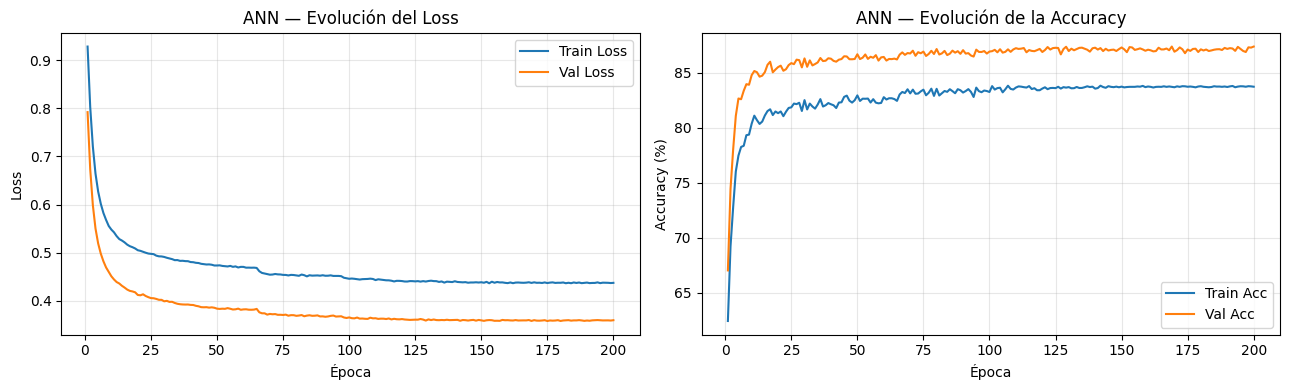

Evaluación en test set
EVALUACIÓN EN TEST SET
Accuracy: 87.12%

              precision    recall  f1-score   support

         P2P       0.97      0.89      0.93    133936
         C2P       0.71      0.85      0.77     32666
         P2C       0.71      0.82      0.76     32318

    accuracy                           0.87    198920
   macro avg       0.80      0.85      0.82    198920
weighted avg       0.89      0.87      0.88    198920



In [33]:
loss_fn_b = nn.CrossEntropyLoss(weight=class_weights)
# loss_fn_b = nn.CrossEntropyLoss()


ds_train   = TensorDataset(X_tr, y_tr_t)
ds_val     = TensorDataset(X_val, y_val_t)
loader_tr  = DataLoader(ds_train, batch_size=ANN_BATCH, shuffle=True,  drop_last=False)
loader_val = DataLoader(ds_val,   batch_size=ANN_BATCH * 4, shuffle=False)

model_b  = EdgeClassifierANN(emb_dim, N_CLASSES, ANN_HIDDEN, ANN_DROPOUT)
opt_b    = torch.optim.Adam(model_b.parameters(), lr=ANN_LR)
sched_b  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_b, mode='min', factor=0.5, patience=5, verbose=False)

train_losses_b, val_losses_b = [], []
train_accs_b,  val_accs_b  = [], []
best_val_b, best_state_b, patience_ctr_b = float('inf'), None, 0

print("=" * 60)
print(f'Con Batches (batch={ANN_BATCH}) ')
print("=" * 60)
for epoch in range(ANN_EPOCHS):
    # ── Train ──
    model_b.train()
    epoch_loss = 0
    for x_b, y_b in loader_tr:
        logits = model_b(x_b)
        loss   = loss_fn_b(logits, y_b)
        opt_b.zero_grad(); loss.backward(); opt_b.step()
        epoch_loss += loss.item()
    avg_train = epoch_loss / len(loader_tr)
    with torch.no_grad():
        tr_correct = sum(
            (model_b(x_b).argmax(1) == y_b).sum().item()
            for x_b, y_b in loader_tr
        )
    train_acc = tr_correct / len(X_tr)


    # ── Val ──
    model_b.eval()
    val_loss, n_correct = 0, 0
    with torch.no_grad():
        for x_b, y_b in loader_val:
            logits = model_b(x_b)
            val_loss  += loss_fn_b(logits, y_b).item()
            n_correct += (logits.argmax(1) == y_b).sum().item()
    avg_val  = val_loss / len(loader_val)
    val_acc  = n_correct / len(X_val)
    train_losses_b.append(avg_train)
    val_losses_b.append(avg_val)
    train_accs_b.append(train_acc)
    val_accs_b.append(val_acc)
    sched_b.step(avg_val)

    if epoch % 10 == 0 or epoch == ANN_EPOCHS - 1:
        print(f'  Epoch {epoch:3d}: train={avg_train:.4f}  '
              f'val={avg_val:.4f}  val_acc={val_acc*100:.2f}%')

    # ── Early stopping ──
    if avg_val < best_val_b:
        best_val_b   = avg_val
        best_state_b = {k: v.clone() for k, v in model_b.state_dict().items()}
        patience_ctr_b = 0
    else:
        patience_ctr_b += 1
    if patience_ctr_b >= ANN_PATIENCE:
        print(f'  Early stopping epoch {epoch}.')
        break

model_b.load_state_dict(best_state_b)
print(f'Mejor val loss (con batches): {best_val_b:.4f}')

# ── Gráfico: Loss y Accuracy durante entrenamiento ──────────────
epochs_ran = len(train_losses_b)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(range(1, epochs_ran + 1), train_losses_b, label="Train Loss")
ax1.plot(range(1, epochs_ran + 1), val_losses_b,   label="Val Loss")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.set_title("ANN — Evolución del Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(range(1, epochs_ran + 1), [a * 100 for a in train_accs_b], label="Train Acc")
ax2.plot(range(1, epochs_ran + 1), [a * 100 for a in val_accs_b],   label="Val Acc")
ax2.set_xlabel("Época")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("ANN — Evolución de la Accuracy")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


############################################################
# Elegir modelo: con batches suele generalizar mejor
############################################################

print("=" * 60)
print('Evaluación en test set')
print("=" * 60)

best_model = model_b  #model_nb

best_model.eval()
all_preds = []
loader_te = DataLoader(TensorDataset(X_test_feat), batch_size=ANN_BATCH * 4)
with torch.no_grad():
    for (x_b,) in loader_te:
        all_preds.append(best_model(x_b).argmax(1))
preds_test = torch.cat(all_preds).numpy()
y_te_np    = y_te_t.numpy()

print('=' * 60)
print('EVALUACIÓN EN TEST SET')
print('=' * 60)
print(f'Accuracy: {accuracy_score(y_te_np, preds_test)*100:.2f}%\n')
print(classification_report(y_te_np, preds_test, target_names=CLASS_NAMES))

### 8. Evaluación Final

Se evalúa el modelo con batches (mejor opción) sobre el conjunto de test.

In [34]:
# Elegir modelo: con batches suele generalizar mejor
best_model = model_b  #model_nb

best_model.eval()
all_preds = []
loader_te = DataLoader(TensorDataset(X_test_feat), batch_size=ANN_BATCH * 4)
with torch.no_grad():
    for (x_b,) in loader_te:
        all_preds.append(best_model(x_b).argmax(1))
preds_test = torch.cat(all_preds).numpy()
y_te_np    = y_te_t.numpy()

print('=' * 60)
print('EVALUACIÓN EN TEST SET')
print('=' * 60)
print(f'Accuracy: {accuracy_score(y_te_np, preds_test)*100:.2f}%\n')
print(classification_report(y_te_np, preds_test, target_names=CLASS_NAMES))


EVALUACIÓN EN TEST SET
Accuracy: 87.12%

              precision    recall  f1-score   support

         P2P       0.97      0.89      0.93    133936
         C2P       0.71      0.85      0.77     32666
         P2C       0.71      0.82      0.76     32318

    accuracy                           0.87    198920
   macro avg       0.80      0.85      0.82    198920
weighted avg       0.89      0.87      0.88    198920



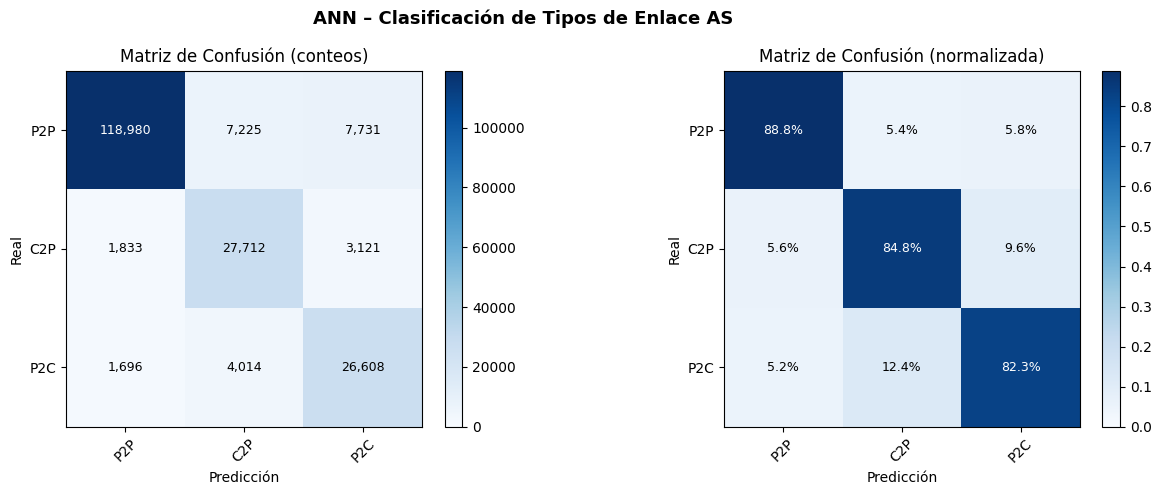

In [35]:
# ── Matrices de confusión ──
save_dir = data_path + f'results/EnfoquePorPartes/{CASO}/'
cm      = confusion_matrix(y_te_np, preds_test)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, title, fmt in [
    (axes[0], cm,      'Matriz de Confusión (conteos)',       lambda v: f'{v:,}'),
    (axes[1], cm_norm, 'Matriz de Confusión (normalizada)',   lambda v: f'{v*100:.1f}%'),
]:
    im = ax.imshow(data, cmap='Blues', vmin=0)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real'); ax.set_title(title)
    thresh = data.max() / 2
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, fmt(data[i, j]), ha='center', va='center',
                    color='white' if data[i, j] > thresh else 'black', fontsize=9)

plt.suptitle('ANN – Clasificación de Tipos de Enlace AS', fontsize=13, fontweight='bold')
plt.tight_layout()
save_dir = save_dir + f'results/EnfoquePorPartes/{CASO}/'
os.makedirs(save_dir, exist_ok=True)
plt.savefig(save_dir + f"results/EnfoquePorPartes/{CASO}/" +'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



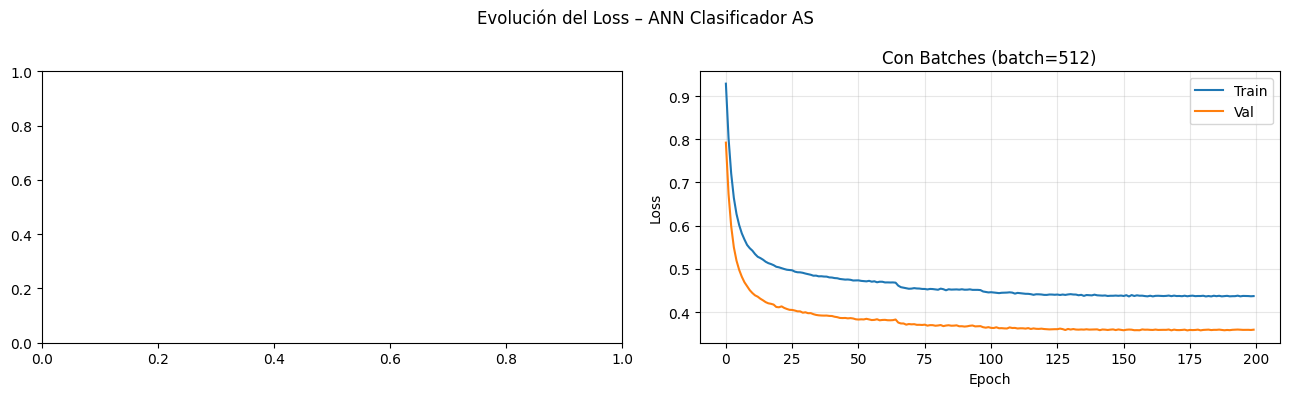

Modelos guardados en /media/vale/KINGSTON/TESIS/data_2026/results/EnfoquePorPartes/Caso5/results/EnfoquePorPartes/Caso5/


In [36]:
# ── Curvas de loss: sin batches vs con batches ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, tr, va, title in [
    # (axes[0], train_losses_nb, val_losses_nb, 'Sin Batches'),
    (axes[1], train_losses_b,  val_losses_b,  f'Con Batches (batch={ANN_BATCH})'),
]:
    ax.plot(tr, label='Train', linewidth=1.5)
    ax.plot(va, label='Val',   linewidth=1.5)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Evolución del Loss – ANN Clasificador AS', fontsize=12)
plt.tight_layout()
plt.savefig(save_dir + 'loss_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Guardar modelos ──
# torch.save(model_nb.state_dict(), save_dir + f'ann_sin_batches_{embeddings_name}.pth')
torch.save(model_b.state_dict(),  save_dir + f'ann_con_batches_{embeddings_name}.pth')
print(f'Modelos guardados en {save_dir}')
